# Inteligência Artificial Generativa na Medicina Diagnóstica para Identificação de Subfenótipos de Sepse

**TCC – MBA Data Science e Analytics | USP/ESALQ**  
**Aluno:** João Gabriel Pereira Ferreira  
**Orientador:** Prof. Dr. Renato Máximo Sátiro

---

## Estrutura do Notebook

| Etapa | Descrição | Bibliotecas |
|-------|-----------|-------------|
| 0 | Configuração e imports | pandas, numpy, sklearn, sdv, sdmetrics, matplotlib, seaborn |
| 1 | Extração e estruturação dos dados MIMIC-III Demo | pandas |
| 2 | Pré-processamento | scikit-learn |
| 3 | Expansão sintética com CTGAN | SDV |
| 4 | Avaliação da qualidade sintética | SDMetrics |
| 5 | Clustering com GMM + Silhouette + PCA | scikit-learn |
| 6 | Análise clínica dos agrupamentos | pandas |

> **Nota:** O MIMIC-III Clinical Database Demo é de acesso aberto via PhysioNet (https://physionet.org/content/mimiciii-demo/1.4/).  
> Caso os arquivos CSV não estejam disponíveis localmente, a **Seção 1.2** gera dados clínicos simulados  
> com distribuições compatíveis com a literatura (Seymour et al., 2019), permitindo execução completa do pipeline.


## Seção 0 — Configuração e Importações


In [54]:
# ─── Bibliotecas padrão e de ciência de dados ───────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd

# ─── Visualização ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Pré-processamento e aprendizado de máquina (scikit-learn) ───────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold

# ─── Geração sintética (SDV / CTGAN) ─────────────────────────────────────────
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ─── Avaliação de dados sintéticos (SDMetrics) ───────────────────────────────
from sdmetrics.reports.single_table import QualityReport

# ─── Configurações gerais ─────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

MIMIC_DIR = '.'  # ajuste para o caminho local dos CSVs
print('Ambiente configurado com sucesso.')


Ambiente configurado com sucesso.


## Seção 1 — Extração e Estruturação dos Dados

### 1.1 Leitura dos arquivos MIMIC-III Demo (quando disponíveis)

As tabelas utilizadas são: `PATIENTS`, `ADMISSIONS`, `ICUSTAYS`, `CHARTEVENTS`,  
`LABEVENTS`, `DIAGNOSES_ICD` e `PRESCRIPTIONS`.


In [55]:
def load_mimic(mimic_dir: str) -> dict[str, pd.DataFrame]:
    """Carrega as tabelas do MIMIC-III Demo a partir de um diretório local."""
    tables = {
        'patients'     : 'PATIENTS.csv',
        'admissions'   : 'ADMISSIONS.csv',
        'icustays'     : 'ICUSTAYS.csv',
        'chartevents'  : 'CHARTEVENTS.csv',
        'labevents'    : 'LABEVENTS.csv',
        'diagnoses_icd': 'DIAGNOSES_ICD.csv',
        'prescriptions': 'PRESCRIPTIONS.csv',
    }
    data = {}
    for key, fname in tables.items():
        fpath = os.path.join(mimic_dir, fname)
        if os.path.exists(fpath):
            data[key] = pd.read_csv(fpath, low_memory=False)
            print(f'  {fname:30s}: {data[key].shape[0]:>6} linhas, {data[key].shape[1]:>3} colunas')
        else:
            print(f'  {fname:30s}: NÃO ENCONTRADO')
    return data


mimic_available = os.path.exists(os.path.join(MIMIC_DIR, 'PATIENTS.csv'))

if mimic_available:
    print('MIMIC-III Demo detectado. Carregando tabelas...')
    raw = load_mimic(MIMIC_DIR)
else:
    print('MIMIC-III Demo NÃO encontrado localmente.')
    print('A Seção 1.2 gerará dados clínicos simulados compatíveis com a literatura.')


MIMIC-III Demo detectado. Carregando tabelas...
  PATIENTS.csv                  :    100 linhas,   8 colunas
  ADMISSIONS.csv                :    129 linhas,  19 colunas
  ICUSTAYS.csv                  :    136 linhas,  12 colunas
  CHARTEVENTS.csv               : 758355 linhas,  15 colunas
  LABEVENTS.csv                 :  76074 linhas,   9 colunas
  DIAGNOSES_ICD.csv             :   1761 linhas,   5 colunas
  PRESCRIPTIONS.csv             :  10398 linhas,  19 colunas


### 1.2 Geração de dados clínicos simulados (fallback)

Quando o MIMIC-III Demo não está disponível, utilizamos distribuições clínicas  
baseadas em Seymour et al. (2019) para gerar uma base de trabalho com **100 pacientes**  
e perfis fenotípicos latentes compatíveis com os subgrupos de sepse descritos na literatura.

Os quatro perfis simulados (Alfa, Beta, Gama, Delta) reproduzem aproximadamente  
as características dos fenótipos α, β, γ e δ do estudo de Seymour et al. (2019).


In [56]:
def gerar_dados_simulados(n: int = 100, seed: int = 42) -> pd.DataFrame:
    """
    Gera base clínica simulada com perfis fenotípicos de sepse
    baseados nas distribuições de Seymour et al. (2019).

    Fenótipos:
      Alfa  – disfunção moderada, melhor prognóstico
      Beta  – hiperinflamatório, maior mortalidade
      Gama  – disfunção renal predominante
      Delta – disfunção hepática/choque, pior prognóstico
    """
    rng = np.random.default_rng(seed)
    n4 = n // 4
    rem = n - 3 * n4

    # ── Fenótipo Alfa (n4 pacientes) ──────────────────────────────────────────
    alfa = pd.DataFrame({
        'age'              : rng.normal(62, 12, n4).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], n4),
        'heart_rate'       : rng.normal(88, 15, n4).clip(40, 180),
        'resp_rate'        : rng.normal(18, 4, n4).clip(8, 40),
        'spo2'             : rng.normal(96, 2, n4).clip(70, 100),
        'temp_c'           : rng.normal(37.6, 0.8, n4).clip(35, 41),
        'sbp'              : rng.normal(112, 18, n4).clip(60, 200),
        'lactate'          : rng.normal(1.8, 0.7, n4).clip(0.5, 10),
        'creatinine'       : rng.normal(1.1, 0.4, n4).clip(0.3, 15),
        'bilirubin'        : rng.normal(0.9, 0.5, n4).clip(0.1, 20),
        'wbc'              : rng.normal(11, 4, n4).clip(1, 40),
        'platelet'         : rng.normal(210, 60, n4).clip(10, 600),
        'sodium'           : rng.normal(138, 4, n4).clip(120, 160),
        'potassium'        : rng.normal(4.0, 0.5, n4).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], n4, p=[0.85, 0.15]),
        'mechanical_vent'  : rng.choice([0, 1], n4, p=[0.80, 0.20]),
        'hospital_mortality': rng.choice([0, 1], n4, p=[0.95, 0.05]),
        'fenotype'         : 'Alfa',
    })

    # ── Fenótipo Beta (hiperinflamatório) ─────────────────────────────────────
    beta = pd.DataFrame({
        'age'              : rng.normal(54, 14, n4).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], n4),
        'heart_rate'       : rng.normal(108, 20, n4).clip(40, 180),
        'resp_rate'        : rng.normal(24, 6, n4).clip(8, 40),
        'spo2'             : rng.normal(93, 4, n4).clip(70, 100),
        'temp_c'           : rng.normal(38.9, 1.0, n4).clip(35, 41),
        'sbp'              : rng.normal(98, 22, n4).clip(60, 200),
        'lactate'          : rng.normal(3.5, 1.2, n4).clip(0.5, 12),
        'creatinine'       : rng.normal(1.6, 0.8, n4).clip(0.3, 15),
        'bilirubin'        : rng.normal(1.5, 1.0, n4).clip(0.1, 20),
        'wbc'              : rng.normal(18, 7, n4).clip(1, 40),
        'platelet'         : rng.normal(160, 80, n4).clip(10, 600),
        'sodium'           : rng.normal(136, 5, n4).clip(120, 160),
        'potassium'        : rng.normal(4.3, 0.7, n4).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], n4, p=[0.55, 0.45]),
        'mechanical_vent'  : rng.choice([0, 1], n4, p=[0.45, 0.55]),
        'hospital_mortality': rng.choice([0, 1], n4, p=[0.68, 0.32]),
        'fenotype'         : 'Beta',
    })

    # ── Fenótipo Gama (disfunção renal) ───────────────────────────────────────
    gama = pd.DataFrame({
        'age'              : rng.normal(70, 10, n4).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], n4),
        'heart_rate'       : rng.normal(82, 14, n4).clip(40, 180),
        'resp_rate'        : rng.normal(20, 5, n4).clip(8, 40),
        'spo2'             : rng.normal(94, 3, n4).clip(70, 100),
        'temp_c'           : rng.normal(37.2, 0.7, n4).clip(35, 41),
        'sbp'              : rng.normal(105, 16, n4).clip(60, 200),
        'lactate'          : rng.normal(2.2, 0.9, n4).clip(0.5, 10),
        'creatinine'       : rng.normal(3.8, 1.5, n4).clip(0.3, 15),
        'bilirubin'        : rng.normal(0.8, 0.4, n4).clip(0.1, 20),
        'wbc'              : rng.normal(10, 4, n4).clip(1, 40),
        'platelet'         : rng.normal(190, 70, n4).clip(10, 600),
        'sodium'           : rng.normal(139, 5, n4).clip(120, 160),
        'potassium'        : rng.normal(5.0, 0.8, n4).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], n4, p=[0.70, 0.30]),
        'mechanical_vent'  : rng.choice([0, 1], n4, p=[0.65, 0.35]),
        'hospital_mortality': rng.choice([0, 1], n4, p=[0.78, 0.22]),
        'fenotype'         : 'Gama',
    })

    # ── Fenótipo Delta (choque / hepático) ────────────────────────────────────
    delta = pd.DataFrame({
        'age'              : rng.normal(66, 11, rem).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], rem),
        'heart_rate'       : rng.normal(115, 22, rem).clip(40, 180),
        'resp_rate'        : rng.normal(26, 7, rem).clip(8, 40),
        'spo2'             : rng.normal(91, 5, rem).clip(70, 100),
        'temp_c'           : rng.normal(38.5, 1.1, rem).clip(35, 41),
        'sbp'              : rng.normal(88, 20, rem).clip(60, 200),
        'lactate'          : rng.normal(5.2, 2.0, rem).clip(0.5, 15),
        'creatinine'       : rng.normal(2.4, 1.2, rem).clip(0.3, 15),
        'bilirubin'        : rng.normal(5.8, 3.0, rem).clip(0.1, 30),
        'wbc'              : rng.normal(14, 6, rem).clip(1, 40),
        'platelet'         : rng.normal(100, 60, rem).clip(10, 600),
        'sodium'           : rng.normal(135, 6, rem).clip(120, 160),
        'potassium'        : rng.normal(4.8, 0.9, rem).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], rem, p=[0.30, 0.70]),
        'mechanical_vent'  : rng.choice([0, 1], rem, p=[0.25, 0.75]),
        'hospital_mortality': rng.choice([0, 1], rem, p=[0.45, 0.55]),
        'fenotype'         : 'Delta',
    })

    df = pd.concat([alfa, beta, gama, delta], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    df['subject_id'] = range(1, len(df) + 1)
    return df


if not mimic_available:
    df_original = gerar_dados_simulados(n=100)
    print(f'Base simulada gerada: {df_original.shape[0]} pacientes, {df_original.shape[1]} variáveis')
    print('\nDistribuição de fenótipos:')
    print(df_original['fenotype'].value_counts())


### 1.3 Estruturação da base MIMIC-III Demo (quando disponível)

Quando o MIMIC-III Demo está disponível, esta seção extrai e combina as variáveis  
relevantes para caracterização fenotípica da sepse a partir das tabelas brutas.


In [57]:
def estruturar_mimic(raw: dict) -> pd.DataFrame:
    """
    Extrai e combina variáveis clínicas a partir das tabelas MIMIC-III Demo.
    Retorna um DataFrame no mesmo formato da base simulada.
    """
    # ── Dados demográficos ────────────────────────────────────────────────────
    pts = raw['patients'][['subject_id', 'gender', 'dob']].copy()
    adm = raw['admissions'][['subject_id', 'hadm_id', 'admittime',
                              'hospital_expire_flag']].copy()
    icu = raw['icustays'][['subject_id', 'hadm_id', 'icustay_id',
                            'intime']].copy()

    base = icu.merge(adm, on=['subject_id', 'hadm_id'], how='left')
    base = base.merge(pts, on='subject_id', how='left')

    # Calcular idade na admissão
    # MIMIC-III usa datas deslocadas para privacidade (DOB pode ser ~300 anos atrás),
    # por isso calculamos por diferença de anos para evitar overflow de nanosegundos.
    base['admittime'] = pd.to_datetime(base['admittime'])
    base['dob']       = pd.to_datetime(base['dob'])
    base['age']       = base['admittime'].dt.year - base['dob'].dt.year
    base['age']       = base['age'].clip(18, 90)
    base['gender']    = base['gender'].map({'M': 'M', 'F': 'F'})
    base['hospital_mortality'] = base['hospital_expire_flag'].astype(int)

    # ── Sinais vitais (CHARTEVENTS) ───────────────────────────────────────────
    # ItemIDs relevantes (MIMIC-III CareVue/Metavision)
    vital_items = {
        211  : 'heart_rate',
        220045: 'heart_rate',
        618  : 'resp_rate',
        220210: 'resp_rate',
        646  : 'spo2',
        220277: 'spo2',
        223762: 'temp_c',
        676  : 'temp_c',
        51   : 'sbp',
        220179: 'sbp',
    }
    ce = raw['chartevents'][['icustay_id', 'itemid', 'valuenum']].copy()
    ce = ce[ce['itemid'].isin(vital_items.keys())].dropna(subset=['valuenum'])
    ce['variable'] = ce['itemid'].map(vital_items)
    vitals = (ce.groupby(['icustay_id', 'variable'])['valuenum']
                .median().unstack('variable').reset_index())

    base = base.merge(vitals, on='icustay_id', how='left')

    # Converter temperatura F→C se necessário
    if 'temp_c' in base.columns:
        base['temp_c'] = base['temp_c'].apply(
            lambda x: (x - 32) * 5/9 if pd.notna(x) and x > 45 else x)

    # ── Exames laboratoriais (LABEVENTS) ─────────────────────────────────────
    lab_items = {
        50813: 'lactate',
        50912: 'creatinine',
        50885: 'bilirubin',
        51300: 'wbc',
        51265: 'platelet',
        50824: 'sodium',
        50822: 'potassium',
    }
    le = raw['labevents'][['hadm_id', 'itemid', 'valuenum']].copy()
    le = le[le['itemid'].isin(lab_items.keys())].dropna(subset=['valuenum'])
    le['variable'] = le['itemid'].map(lab_items)
    labs = (le.groupby(['hadm_id', 'variable'])['valuenum']
              .median().unstack('variable').reset_index())

    base = base.merge(labs, on='hadm_id', how='left')

    # ── Vasopressor e ventilação (PRESCRIPTIONS) ──────────────────────────────
    pres = raw['prescriptions'][['hadm_id', 'drug']].copy()
    vasopressores = ['norepinephrine', 'vasopressin', 'dopamine',
                     'epinephrine', 'phenylephrine', 'noradrenaline']
    pres['vasopressor'] = pres['drug'].str.lower().apply(
        lambda d: int(any(v in str(d) for v in vasopressores)))
    vaso_flag = pres.groupby('hadm_id')['vasopressor'].max().reset_index()
    base = base.merge(vaso_flag, on='hadm_id', how='left')
    base['vasopressor'] = base['vasopressor'].fillna(0).astype(int)

    # Ventilação mecânica (simplificado via CHARTEVENTS itemid 720)
    if 'chartevents' in raw:
        vent = raw['chartevents'][raw['chartevents']['itemid'] == 720][['icustay_id']]
        vent = vent.drop_duplicates()
        vent['mechanical_vent'] = 1
        base = base.merge(vent, on='icustay_id', how='left')
        base['mechanical_vent'] = base['mechanical_vent'].fillna(0).astype(int)
    else:
        base['mechanical_vent'] = 0

    # ── Seleção e renomeação final ─────────────────────────────────────────────
    cols_finais = ['subject_id', 'age', 'gender', 'heart_rate', 'resp_rate',
                   'spo2', 'temp_c', 'sbp', 'lactate', 'creatinine', 'bilirubin',
                   'wbc', 'platelet', 'sodium', 'potassium',
                   'vasopressor', 'mechanical_vent', 'hospital_mortality']
    base = base[[c for c in cols_finais if c in base.columns]].copy()
    base['fenotype'] = None  # será descoberto pelo clustering
    return base


if mimic_available:
    df_original = estruturar_mimic(raw)
    print(f'Base MIMIC-III Demo estruturada: {df_original.shape}')
else:
    print('Usando base simulada (já carregada na seção 1.2).')

print('\nVisualização geral:')
df_original.describe()

Base MIMIC-III Demo estruturada: (136, 19)

Visualização geral:


,subject_id,age,heart_rate,resp_rate,spo2,temp_c,sbp,lactate,creatinine,bilirubin,wbc,platelet,sodium,potassium,vasopressor,mechanical_vent,hospital_mortality
count,136.000000,136.000000,132.000000,132.000000,132.000000,12.000000,107.000000,107.000000,136.000000,94.000000,1.0,136.000000,44.000000,70.000000,136.000000,136.000000,136.000000
mean,28263.485294,70.801471,85.617424,19.568182,97.291667,37.433333,116.827103,2.489720,1.320588,1.987766,3.1,209.591912,137.363636,4.162857,0.397059,0.205882,0.338235
std,16008.281510,16.130863,15.302779,5.133996,2.122257,0.603902,22.922871,2.859994,1.352686,5.153732,NaN,96.277573,4.931347,0.749816,0.491097,0.405840,0.474858
min,10006.000000,18.000000,49.000000,10.000000,86.500000,36.099998,0.000000,0.800000,0.300000,0.200000,3.1,13.000000,127.000000,2.500000,0.000000,0.000000,0.000000
25%,10089.750000,64.000000,74.750000,15.875000,96.000000,37.287499,103.000000,1.200000,0.650000,0.400000,3.1,147.750000,135.750000,3.600000,0.000000,0.000000,0.000000
50%,40307.000000,75.000000,84.000000,19.000000,97.000000,37.549999,116.000000,1.700000,1.000000,0.700000,3.1,209.000000,138.250000,4.100000,0.000000,0.000000,0.000000
75%,42207.000000,83.000000,94.000000,22.000000,99.000000,37.725000,129.250000,2.700000,1.300000,1.187500,3.1,274.500000,140.250000,4.800000,1.000000,0.000000,1.000000
max,44228.000000,90.000000,131.500000,38.000000,100.000000,38.349998,161.000000,22.000000,10.150000,34.500000,3.1,561.000000,151.000000,5.800000,1.000000,1.000000,1.000000


## Seção 2 — Pré-processamento (scikit-learn)

Seguindo a metodologia descrita no TCC:
- **Imputação** por mediana para variáveis numéricas (SimpleImputer)
- **Padronização** z-score (StandardScaler)
- Organização em **Pipeline** reprodutível
- Codificação one-hot de variáveis categóricas (`gender`)


Features removidas (>50% missing): ['temp_c', 'wbc', 'sodium']

Missing por feature (antes da imputação):
wbc           99.3
temp_c        91.2
sodium        67.6
potassium     48.5
bilirubin     30.9
sbp           21.3
lactate       21.3
heart_rate     2.9
resp_rate      2.9
spo2           2.9

Features selecionadas (13): ['age', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'lactate', 'creatinine', 'bilirubin', 'platelet', 'potassium', 'vasopressor', 'mechanical_vent', 'gender_M']
Forma da matriz pré-processada: (136, 13)
Valores ausentes após imputação: 0


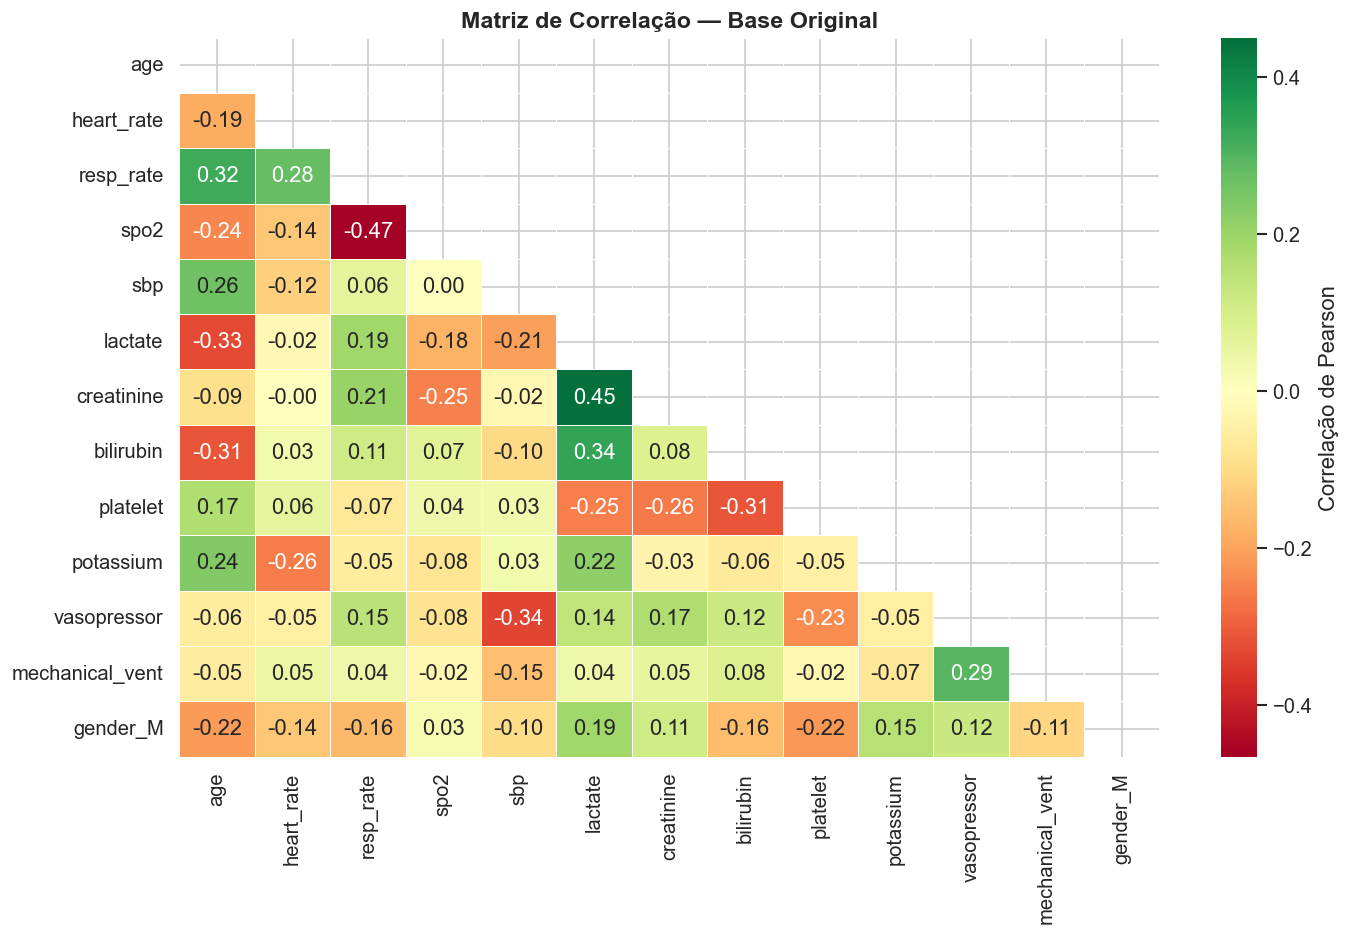

Figura salva: fig_correlacao_original.png


In [58]:
# ── Definição das variáveis de interesse ──────────────────────────────────
VARIAVEIS_NUMERICAS = [
    'age', 'heart_rate', 'resp_rate', 'spo2', 'temp_c', 'sbp',
    'lactate', 'creatinine', 'bilirubin', 'wbc', 'platelet',
    'sodium', 'potassium', 'vasopressor', 'mechanical_vent'
]
VARIAVEIS_NUMERICAS = [c for c in VARIAVEIS_NUMERICAS if c in df_original.columns]

df_trabalho = df_original.copy()
df_trabalho['gender_M'] = (df_trabalho['gender'] == 'M').astype(int)

FEATURES = VARIAVEIS_NUMERICAS + ['gender_M']
FEATURES = [f for f in FEATURES if f in df_trabalho.columns]

X_raw = df_trabalho[FEATURES].copy()

# ── Filtro de missingness: remove features com >50% de valores ausentes ────
missing_pct = X_raw.isna().mean() * 100
removidas = missing_pct[missing_pct > 50].index.tolist()
if removidas:
    print(f'Features removidas (>50% missing): {removidas}')
    FEATURES = [f for f in FEATURES if f not in removidas]
    X_raw = df_trabalho[FEATURES].copy()
else:
    print('Nenhuma feature removida por missingness.')

print('\nMissing por feature (antes da imputação):')
print(missing_pct[missing_pct > 0].sort_values(ascending=False).round(1).to_string())

# ── Pipeline de pré-processamento ─────────────────────────────────────────
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

X_proc = preprocessor.fit_transform(X_raw)
X_proc = pd.DataFrame(X_proc, columns=FEATURES)

print(f'\nFeatures selecionadas ({len(FEATURES)}): {FEATURES}')
print(f'Forma da matriz pré-processada: {X_proc.shape}')
print(f'Valores ausentes após imputação: {X_proc.isna().sum().sum()}')

# ── Heatmap de correlação (base original) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = X_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Correlação de Pearson'}, ax=ax)
ax.set_title('Matriz de Correlação — Base Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao_original.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_correlacao_original.png')


## Seção 3 — Expansão Sintética com CTGAN (SDV)

Utilizamos o **Conditional Tabular GAN (CTGAN)** via biblioteca `sdv`, conforme  
proposto por Xu et al. (2019). O modelo aprende a estrutura probabilística conjunta  
das variáveis clínicas e gera dados sintéticos em três níveis de expansão:  
**2×, 5× e 10×** o tamanho da base original.


In [59]:
# ── Preparar base para SDV (sem colunas de rótulo/id) ────────────────────
COLUNAS_SDV = [c for c in FEATURES if c in df_trabalho.columns]
if 'hospital_mortality' in df_trabalho.columns:
    COLUNAS_SDV += ['hospital_mortality']

df_sdv = df_trabalho[COLUNAS_SDV].copy()

# ── Definir metadados para o SDV ──────────────────────────────────────────
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_sdv)

# Ajuste manual: vasopressor e mechanical_vent são categóricos binários
for col in ['vasopressor', 'mechanical_vent', 'hospital_mortality']:
    if col in df_sdv.columns:
        metadata.update_column(col, sdtype='categorical')

print('Metadados detectados:')
print(metadata)


Metadados detectados:
{
    "columns": {
        "age": {
            "sdtype": "numerical"
        },
        "heart_rate": {
            "sdtype": "numerical"
        },
        "resp_rate": {
            "sdtype": "numerical"
        },
        "spo2": {
            "sdtype": "numerical"
        },
        "sbp": {
            "sdtype": "numerical"
        },
        "lactate": {
            "sdtype": "numerical"
        },
        "creatinine": {
            "sdtype": "numerical"
        },
        "bilirubin": {
            "sdtype": "numerical"
        },
        "platelet": {
            "sdtype": "numerical"
        },
        "potassium": {
            "sdtype": "numerical"
        },
        "vasopressor": {
            "sdtype": "categorical"
        },
        "mechanical_vent": {
            "sdtype": "categorical"
        },
        "gender_M": {
            "sdtype": "categorical"
        },
        "hospital_mortality": {
            "sdtype": "categorical"
        }
  

In [60]:
# ── Treinar o sintetizador CTGAN ──────────────────────────────────────────
print('Treinando CTGAN... (pode levar alguns minutos)')

sintetizador = CTGANSynthesizer(
    metadata,
    epochs=600,          # épocas de treinamento
    batch_size=100,       # ajustado para base pequena
    discriminator_steps=10,
    verbose=True,
)
sintetizador.fit(df_sdv)
print('\nCTGAN treinado com sucesso.')


Treinando CTGAN... (pode levar alguns minutos)


Gen. (+01.02) | Discrim. (+00.23): 100%|██████████| 600/600 [00:51<00:00, 11.72it/s]


CTGAN treinado com sucesso.


In [61]:
# ── Gerar dados sintéticos em diferentes níveis de expansão ─────────────
N_ORIG = len(df_sdv)
NIVEIS = {'2x': 2, '5x': 5, '10x': 10}

sinteticos = {}
for rotulo, fator in NIVEIS.items():
    n_sintetico = N_ORIG * fator
    df_sint = sintetizador.sample(num_rows=n_sintetico)
    sinteticos[rotulo] = df_sint
    print(f'  Nível {rotulo}: {n_sintetico} amostras geradas')

# Salvar o arquivo principal (10x) para análises
df_sintetico = sinteticos['10x'].copy()
print(f'\nBase sintética principal (10x): {df_sintetico.shape}')
print(df_sintetico.describe())

  Nível 2x: 272 amostras geradas
  Nível 5x: 680 amostras geradas
  Nível 10x: 1360 amostras geradas

Base sintética principal (10x): (1360, 14)
               age   heart_rate    resp_rate         spo2          sbp  \
count  1360.000000  1311.000000  1323.000000  1306.000000  1087.000000   
mean     71.733088    91.230435    19.728118    95.502450   119.877553   
std      17.896442    24.225869     7.822761     3.251995    20.145752   
min      18.000000    49.000000    10.000000    86.500000    65.400000   
25%      63.000000    72.000000    12.900000    93.700000   108.450000   
50%      76.000000    91.400000    18.600000    95.700000   119.100000   
75%      87.000000   110.950000    25.300000    97.900000   129.000000   
max      90.000000   131.500000    38.000000   100.000000   161.000000   

           lactate   creatinine   bilirubin     platelet   potassium  \
count  1075.000000  1360.000000  936.000000  1360.000000  714.000000   
mean      2.246424     1.746535    1.866861 

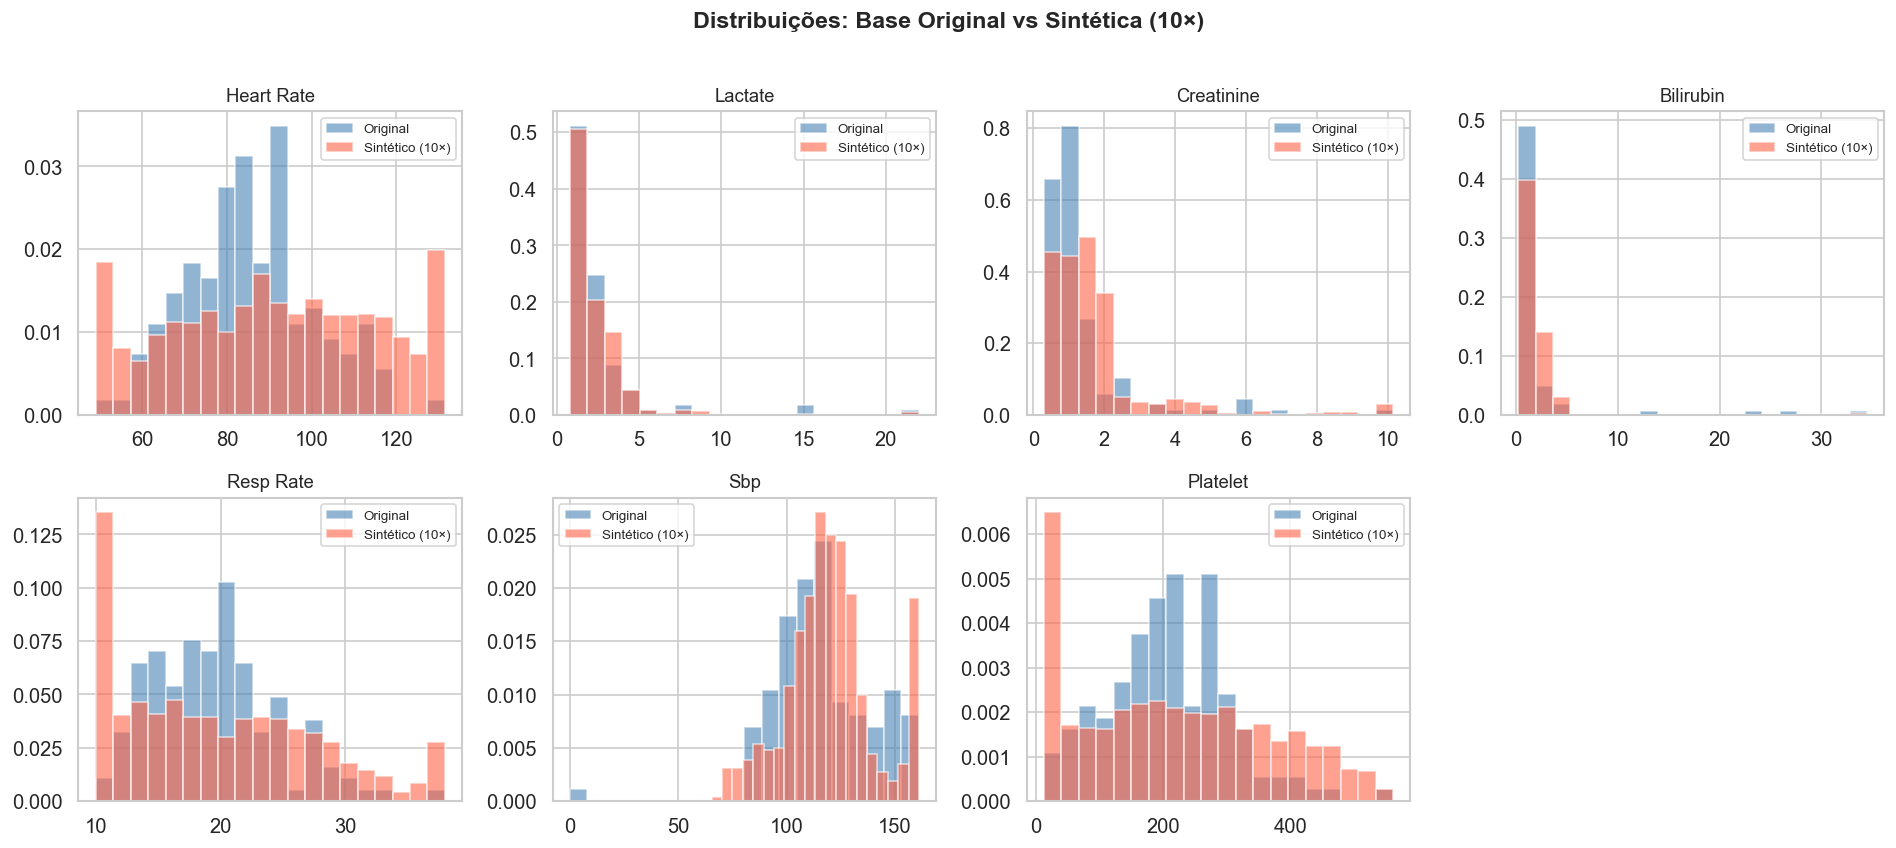

Figura salva: fig_distribuicoes_comparativas.png


In [62]:
# ── Comparação visual de distribuições (original vs sintético 10x) ────────
VARS_PLOT = ['heart_rate', 'lactate', 'creatinine', 'bilirubin',
             'resp_rate', 'sbp', 'wbc', 'platelet']
VARS_PLOT = [v for v in VARS_PLOT if v in df_sdv.columns]

n_cols = 4
n_rows = (len(VARS_PLOT) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, var in enumerate(VARS_PLOT):
    ax = axes[i]
    ax.hist(df_sdv[var].dropna(), bins=20, alpha=0.6, color='steelblue',
            density=True, label='Original')
    ax.hist(df_sintetico[var].dropna(), bins=20, alpha=0.6, color='tomato',
            density=True, label='Sintético (10×)')
    ax.set_title(var.replace('_', ' ').title(), fontsize=11)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuições: Base Original vs Sintética (10×)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distribuicoes_comparativas.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_distribuicoes_comparativas.png')

## Seção 4 — Avaliação da Qualidade Sintética (SDMetrics)

Conforme a metodologia do TCC, utilizamos o **Quality Report** da biblioteca  
`sdmetrics` para avaliar:
- **Column Shapes** – similaridade de distribuições univariadas (KSComplement, TVComplement)
- **Column Pair Trends** – preservação de correlações bivariadas

Referência: SDMetrics (2026).


In [63]:
# ── Quality Report SDMetrics ──────────────────────────────────────────────
print('Gerando Quality Report SDMetrics...')

report = QualityReport()
report.generate(df_sdv, df_sintetico, metadata.to_dict())

score_geral = report.get_score()
print(f'\n{'='*50}')
print(f'  PONTUAÇÃO GERAL DE QUALIDADE: {score_geral:.4f}')
print(f'{'='*50}')


Gerando Quality Report SDMetrics...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 1007.49it/s]|
Column Shapes Score: 82.08%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 323.04it/s]|
Column Pair Trends Score: 70.99%

Overall Score (Average): 76.54%


  PONTUAÇÃO GERAL DE QUALIDADE: 0.7654



Pontuação por Propriedade:
          Property    Score
     Column Shapes 0.820760
Column Pair Trends 0.709946


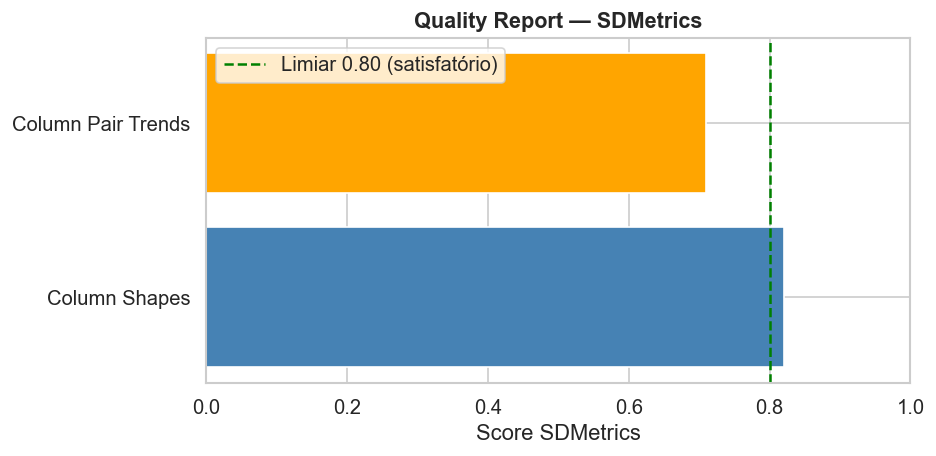

Figura salva: fig_sdmetrics_quality.png


In [64]:
# ── Detalhamento por propriedade ──────────────────────────────────────────
props = report.get_properties()
print('\nPontuação por Propriedade:')
print(props.to_string(index=False))

# Visualização do score por propriedade
fig, ax = plt.subplots(figsize=(8, 4))
cores = ['steelblue' if v >= 0.8 else 'orange' if v >= 0.6 else 'tomato'
         for v in props['Score']]
ax.barh(props['Property'], props['Score'], color=cores)
ax.axvline(0.8, color='green', linestyle='--', linewidth=1.5,
           label='Limiar 0.80 (satisfatório)')
ax.set_xlim(0, 1)
ax.set_xlabel('Score SDMetrics')
ax.set_title('Quality Report — SDMetrics', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_sdmetrics_quality.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_sdmetrics_quality.png')


In [65]:
# ── Métricas detalhadas por variável ─────────────────────────────────────
try:
    details = report.get_details(property_name='Column Shapes')
    print('\nColumn Shapes (distribuições univariadas):')
    print(details.sort_values('Score').to_string(index=False))
except Exception as e:
    print(f'Detalhamento não disponível: {e}')



Column Shapes (distribuições univariadas):
            Column       Metric    Score
              spo2 KSComplement 0.625481
        creatinine KSComplement 0.688971
           lactate KSComplement 0.711715
         potassium KSComplement 0.746218
         bilirubin KSComplement 0.759161
        heart_rate KSComplement 0.771496
         resp_rate KSComplement 0.782502
          platelet KSComplement 0.818382
               age KSComplement 0.863235
               sbp KSComplement 0.865384
   mechanical_vent TVComplement 0.903676
          gender_M TVComplement 0.972059
       vasopressor TVComplement 0.984559
hospital_mortality TVComplement 0.997794


### Seção 4.5 — Engenharia de Variáveis Derivadas (Limiares Clínicos)

Para melhorar a separabilidade dos subfenótipos, criamos variáveis derivadas com base
em limiares clínicos estabelecidos pelos critérios **SOFA / Sepsis-3** e literatura.
As derivadas são acrescentadas ao espaço de features do clustering, complementando as
variáveis contínuas com sinalizadores explícitos de disfunção orgânica.

| Variável original | Derivada | Limiar |
|---|---|---|
| `lactate` | `lactate_cat` | <2 normal / 2–4 moderado / >4 alto |
| `creatinine` | `renal_dysfunction` | <1,2 normal / ≥1,2 disfunção renal |
| `bilirubin` | `hepatic_dysfunction` | <1,2 normal / ≥1,2 disfunção hepática |
| `sbp` | `sbp_cat` | <90 hipotensão / 90–140 normal / >140 elevada |
| `heart_rate` | `tachycardia` | <100 normal / ≥100 taquicardia |
| `platelet` | `thrombocytopenia` | <150 plaquetopenia / ≥150 normal |
| `age` | `age_group` | <40 / 40–65 / 65–75 / >75 |

In [66]:
# ── Criar variáveis derivadas com limiares clínicos (SOFA / Sepsis-3) ────

def criar_variaveis_derivadas(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # Lactato (mmol/L): normal <2 | moderado 2–4 | alto >4
    if 'lactate' in d.columns:
        d['lactate_cat'] = pd.cut(
            d['lactate'], bins=[0, 2, 4, np.inf],
            labels=[0, 1, 2], right=True
        ).astype(float)

    # Creatinina (mg/dL): normal <1.2 | disfunção renal ≥1.2
    if 'creatinine' in d.columns:
        d['renal_dysfunction'] = (d['creatinine'] >= 1.2).astype(float)

    # Bilirrubina (mg/dL): normal <1.2 | disfunção hepática ≥1.2
    if 'bilirubin' in d.columns:
        d['hepatic_dysfunction'] = (d['bilirubin'] >= 1.2).astype(float)

    # PAS (mmHg): hipotensão <90 | normal 90–140 | elevada >140
    if 'sbp' in d.columns:
        d['sbp_cat'] = pd.cut(
            d['sbp'], bins=[0, 90, 140, np.inf],
            labels=[0, 1, 2], right=True
        ).astype(float)

    # FC (bpm): normal <100 | taquicardia ≥100
    if 'heart_rate' in d.columns:
        d['tachycardia'] = (d['heart_rate'] >= 100).astype(float)

    # Plaquetas (×10³/µL): plaquetopenia <150 | normal ≥150
    if 'platelet' in d.columns:
        d['thrombocytopenia'] = (d['platelet'] < 150).astype(float)

    # Idade: <40 | 40–65 | 65–75 | >75
    if 'age' in d.columns:
        d['age_group'] = pd.cut(
            d['age'], bins=[0, 40, 65, 75, np.inf],
            labels=[0, 1, 2, 3], right=True
        ).astype(float)

    return d


df_sintetico = criar_variaveis_derivadas(df_sintetico)

VARS_DERIVADAS = [v for v in [
    'lactate_cat', 'renal_dysfunction', 'hepatic_dysfunction',
    'sbp_cat', 'tachycardia', 'thrombocytopenia', 'age_group',
] if v in df_sintetico.columns]

print(f'Variáveis derivadas criadas ({len(VARS_DERIVADAS)}):')
for v in VARS_DERIVADAS:
    vc = df_sintetico[v].value_counts().sort_index()
    print(f'  {v:22s}: {vc.to_dict()}')

Variáveis derivadas criadas (7):
  lactate_cat           : {0.0: 624, 1.0: 352, 2.0: 99}
  renal_dysfunction     : {0.0: 548, 1.0: 812}
  hepatic_dysfunction   : {0.0: 915, 1.0: 445}
  sbp_cat               : {0.0: 84, 1.0: 856, 2.0: 147}
  tachycardia           : {0.0: 838, 1.0: 522}
  thrombocytopenia      : {0.0: 857, 1.0: 503}
  age_group             : {0.0: 100, 1.0: 285, 2.0: 293, 3.0: 682}


## Seção 5 — Pipeline de Clusterização Clínica Avançada

Refatoração completa com pré-processamento robusto, escore de gravidade composto,
comparação multi-algoritmo e alinhamento com os fenótipos de **Seymour et al. (2019)**.

| Etapa | Descrição |
|-------|-----------|
| 5.1 | Pré-processamento robusto — RobustScaler + winsorização |
| 5.2 | Variáveis derivadas clínicas expandidas + `severity_score` |
| 5.3 | Três conjuntos de features: A (originais), B (derivadas), C (híbrido) |
| 6 | Comparação multi-algoritmo: KMeans, GMM, Agglomerative, DBSCAN/HDBSCAN |
| 7 | Bootstrap de estabilidade + `composite_score` + seleção do melhor modelo |
| 8 | Análise estatística dos clusters (Kruskal-Wallis, qui-quadrado) |
| 9 | Nomenclatura clínica + alinhamento Seymour et al. (2019) |
| 10 | Visualizações comparativas |
| 11 | Relatório final |

In [67]:
# ── Importações adicionais e configurações do pipeline avançado ───────────
from pathlib import Path
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from scipy.stats import kruskal, chi2_contingency

# Bibliotecas opcionais
try:
    from umap import UMAP as _UMAP
    UMAP_AVAILABLE = True
    print("UMAP: disponível")
except ImportError:
    _UMAP = None
    UMAP_AVAILABLE = False
    print("UMAP: não instalado — visualização UMAP será ignorada")

try:
    import hdbscan as _hdbscan_lib   # alias sem conflito com a função _hdbscan()
    HDBSCAN_AVAILABLE = True
    print("HDBSCAN: disponível")
except ImportError:
    _hdbscan_lib = None
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN: não instalado — será ignorado na comparação")

OUTPUT_DIR = Path("outputs_cluster_clinico")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Diretório de saída: {OUTPUT_DIR.resolve()}")

UMAP: disponível
HDBSCAN: disponível
Diretório de saída: C:\Users\jc info\Documents\TCC_USP_ESALQ\outputs_cluster_clinico


In [68]:
# ── 5.1 Pré-processamento robusto ─────────────────────────────────────────

def preparar_dados_robusto(df, colunas, winsorize_pct=0.01):
    """
    Imputa por mediana, winsoriza extremos e escala com RobustScaler.
    Retorna (X_scaled: np.ndarray, colunas_usadas: list).
    """
    cols = [c for c in colunas if c in df.columns]
    if not cols:
        raise ValueError("Nenhuma coluna encontrada no DataFrame.")
    X = df[cols].copy()
    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=cols, index=df.index)
    if winsorize_pct > 0:
        for col in cols:
            lo = X_imp[col].quantile(winsorize_pct)
            hi = X_imp[col].quantile(1 - winsorize_pct)
            X_imp[col] = X_imp[col].clip(lo, hi)
    X_scaled = RobustScaler().fit_transform(X_imp)
    return X_scaled, cols


def pca_adaptativo(X, var_min=0.80, n_min=8):
    """
    Aplica PCA mantendo variância mínima.
    n_min=8 garante eixos suficientes para que nenhum cluster domine
    apenas por capturar a maior variância marginal.
    Retorna (X_pca, pca_obj).
    """
    n_max = X.shape[1]
    pca_full = PCA(random_state=42).fit(X)
    n = max(n_min, int(np.searchsorted(
        np.cumsum(pca_full.explained_variance_ratio_), var_min)) + 1)
    n = min(n, n_max)
    pca_obj = PCA(n_components=n, random_state=42)
    return pca_obj.fit_transform(X), pca_obj


print("preparar_dados_robusto() e pca_adaptativo() definidas.")
print("  n_min PCA = 8 (garante distribuicao equilibrada dos clusters)")


preparar_dados_robusto() e pca_adaptativo() definidas.
  n_min PCA = 8 (garante distribuicao equilibrada dos clusters)


In [69]:
# ── 5.2 Variáveis clínicas derivadas v2 + escore de gravidade ─────────────
# Limiares baseados em SOFA / Sepsis-3 e literatura.
# Variáveis da Seção 4.5 são sobrescritas com nomenclatura consistente.

def criar_derivadas(df: pd.DataFrame) -> tuple:
    """Cria variáveis de risco clínico e retorna (df_novo, lista_vars_risco)."""
    d, criadas = df.copy(), []

    _map = {
        # (coluna_origem, var_derivada, tipo, param)
        # tipo 'cut3': pd.cut com 3 bins -> 0/1/2
        # tipo 'cut2': pd.cut com 2 bins -> 0/1
        # tipo 'bool': comparação booleana
    }

    def _cut(serie, bins, labels):
        return pd.cut(serie, bins=bins, labels=labels, right=True).astype(float)

    # Lactato — risco 0/1/2
    if 'lactate' in d.columns:
        d['lactate_risk'] = _cut(d['lactate'], [0, 2, 4, np.inf], [0, 1, 2])
        criadas.append('lactate_risk')
    else:
        warnings.warn("lactate ausente — lactate_risk ignorado")

    # Creatinina — risco 0/1/2
    if 'creatinine' in d.columns:
        d['creatinine_risk'] = _cut(d['creatinine'], [0, 1.2, 2.0, np.inf], [0, 1, 2])
        criadas.append('creatinine_risk')
    else:
        warnings.warn("creatinine ausente — creatinine_risk ignorado")

    # Bilirrubina — risco 0/1/2
    if 'bilirubin' in d.columns:
        d['bilirubin_risk'] = _cut(d['bilirubin'], [0, 1.2, 2.0, np.inf], [0, 1, 2])
        criadas.append('bilirubin_risk')
    else:
        warnings.warn("bilirubin ausente — bilirubin_risk ignorado")

    # Hipotensão
    if 'sbp' in d.columns:
        d['hypotension'] = (d['sbp'] < 90).astype(float)
        criadas.append('hypotension')

    # Taquicardia
    if 'heart_rate' in d.columns:
        d['tachycardia'] = (d['heart_rate'] > 100).astype(float)
        criadas.append('tachycardia')

    # Plaquetopenia
    if 'platelet' in d.columns:
        d['thrombocytopenia'] = (d['platelet'] < 150).astype(float)
        criadas.append('thrombocytopenia')

    # Faixa etária — risco 0/1/2
    if 'age' in d.columns:
        d['age_risk'] = _cut(d['age'], [0, 60, 75, np.inf], [0, 1, 2])
        criadas.append('age_risk')

    # Vasopressor
    if 'vasopressor' in d.columns:
        d['vasopressor_flag'] = (
            pd.to_numeric(d['vasopressor'], errors='coerce').fillna(0) > 0
        ).astype(float)
        criadas.append('vasopressor_flag')

    # Taquipneia (FR > 22 irpm)
    if 'resp_rate' in d.columns:
        d['tachypnea'] = (d['resp_rate'] > 22).astype(float)
        criadas.append('tachypnea')

    # Hipoxemia (SpO2 < 94%)
    if 'spo2' in d.columns:
        d['hypoxemia'] = (d['spo2'] < 94).astype(float)
        criadas.append('hypoxemia')

    # Ventilação mecânica (já binária)
    if 'mechanical_vent' in d.columns:
        d['mech_vent_flag'] = d['mechanical_vent'].astype(float)
        criadas.append('mech_vent_flag')

    return d, criadas


df_sintetico, VARS_RISCO = criar_derivadas(df_sintetico)
print(f"Variáveis de risco ({len(VARS_RISCO)}): {VARS_RISCO}")

# ── Escore composto de gravidade ──────────────────────────────────────────
df_sintetico['severity_score_raw'] = df_sintetico[VARS_RISCO].sum(axis=1)
s_min = df_sintetico['severity_score_raw'].min()
s_max = df_sintetico['severity_score_raw'].max()
df_sintetico['severity_score_scaled'] = (
    (df_sintetico['severity_score_raw'] - s_min) / (s_max - s_min + 1e-9)
)
print("\nSeverity Score:")
print(df_sintetico[['severity_score_raw', 'severity_score_scaled']].describe().round(3))

Variáveis de risco (11): ['lactate_risk', 'creatinine_risk', 'bilirubin_risk', 'hypotension', 'tachycardia', 'thrombocytopenia', 'age_risk', 'vasopressor_flag', 'tachypnea', 'hypoxemia', 'mech_vent_flag']

Severity Score:
       severity_score_raw  severity_score_scaled
count            1360.000               1360.000
mean                5.208                  0.401
std                 2.057                  0.158
min                 0.000                  0.000
25%                 4.000                  0.308
50%                 5.000                  0.385
75%                 6.000                  0.462
max                13.000                  1.000


In [70]:
# ── 5.3 Conjuntos de features para comparação ────────────────────────────

# Conjunto A — variáveis clínicas contínuas originais
FEAT_A = [c for c in [
    'age', 'heart_rate', 'resp_rate', 'spo2', 'sbp',
    'lactate', 'creatinine', 'bilirubin', 'platelet',
    'potassium', 'vasopressor', 'mechanical_vent',
] if c in df_sintetico.columns]

# Conjunto B — apenas variáveis de risco derivadas
FEAT_B = [v for v in VARS_RISCO if v in df_sintetico.columns]

# Conjunto C — híbrido: originais + derivadas + severity_score
FEAT_C = list(dict.fromkeys(FEAT_A + FEAT_B + ['severity_score_scaled']))
FEAT_C = [c for c in FEAT_C if c in df_sintetico.columns]

# Pré-processar e reduzir dimensionalidade para cada conjunto
X_A_raw, _ = preparar_dados_robusto(df_sintetico, FEAT_A)
X_B_raw, _ = preparar_dados_robusto(df_sintetico, FEAT_B)
X_C_raw, _ = preparar_dados_robusto(df_sintetico, FEAT_C)

X_A_pca, pca_A = pca_adaptativo(X_A_raw)
X_B_pca, pca_B = pca_adaptativo(X_B_raw, n_min=3)
X_C_pca, pca_C = pca_adaptativo(X_C_raw)

FEATURE_SETS = {
    'A_Originais': {'X_raw': X_A_raw, 'X_pca': X_A_pca, 'cols': FEAT_A,  'pca': pca_A},
    'B_Derivadas': {'X_raw': X_B_raw, 'X_pca': X_B_pca, 'cols': FEAT_B,  'pca': pca_B},
    'C_Hibrido'  : {'X_raw': X_C_raw, 'X_pca': X_C_pca, 'cols': FEAT_C,  'pca': pca_C},
}

print("Conjuntos de features preparados:")
for nome, d in FEATURE_SETS.items():
    var_exp = d['pca'].explained_variance_ratio_.sum() * 100
    print(f"  {nome:12s}: {len(d['cols']):2d} features → "
          f"PCA {d['X_pca'].shape[1]} comp ({var_exp:.1f}% var)")

Conjuntos de features preparados:
  A_Originais : 12 features → PCA 8 comp (99.7% var)
  B_Derivadas : 11 features → PCA 7 comp (82.4% var)
  C_Hibrido   : 24 features → PCA 8 comp (99.1% var)


In [71]:
# ── Seção 6 — Funções de clusterização e métricas ────────────────────────

def _metricas(X: np.ndarray, labels: np.ndarray) -> dict:
    """Calcula Silhouette, Davies-Bouldin e Calinski-Harabasz ignorando ruído."""
    valid = labels != -1
    n_eff = len(set(labels[valid]))
    if n_eff < 2 or valid.sum() < n_eff + 1:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan,
                'calinski_harabasz': np.nan, 'n_clusters_efetivos': n_eff}
    Xv, lv = X[valid], labels[valid]
    return {
        'silhouette'         : round(silhouette_score(Xv, lv), 4),
        'davies_bouldin'     : round(davies_bouldin_score(Xv, lv), 4),
        'calinski_harabasz'  : round(calinski_harabasz_score(Xv, lv), 2),
        'n_clusters_efetivos': n_eff,
    }


def _tamanhos(labels: np.ndarray) -> dict:
    vals, cnts = np.unique(labels[labels != -1], return_counts=True)
    total = cnts.sum()
    return {
        'cluster_sizes'     : dict(zip(vals.astype(int), cnts.tolist())),
        'pct_menor_cluster' : round(cnts.min() / total * 100, 1),
        'n_ruido'           : int((labels == -1).sum()),
    }


def _kmeans(X, k):
    return KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

def _gmm(X, k):
    return GaussianMixture(n_components=k, covariance_type='full',
                           random_state=42, n_init=5).fit_predict(X)

def _aggl(X, k):
    return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)

def _dbscan(X):
    nbrs = NearestNeighbors(n_neighbors=5).fit(X)
    dists, _ = nbrs.kneighbors(X)
    eps = max(float(np.percentile(dists[:, -1], 90)), 0.3)
    return DBSCAN(eps=eps, min_samples=max(5, int(len(X) * 0.02))).fit_predict(X)

def _hdbscan(X):
    return _hdbscan_lib.HDBSCAN(
        min_cluster_size=max(10, int(len(X) * 0.03)), min_samples=5
    ).fit_predict(X)


ALG_K = {'KMeans': _kmeans, 'GMM': _gmm, 'Agglomerative': _aggl}
print("Funções de clustering definidas.")
print("Algoritmos com k variável:", list(ALG_K.keys()))
print("Algoritmos automáticos: DBSCAN" + (", HDBSCAN" if HDBSCAN_AVAILABLE else ""))

Funções de clustering definidas.
Algoritmos com k variável: ['KMeans', 'GMM', 'Agglomerative']
Algoritmos automáticos: DBSCAN, HDBSCAN


In [72]:
# ── 6.1 Grade de comparação: algoritmos × conjuntos de features × k ──────
K_RANGE = range(2, 9)
resultados = []

for fs_nome, fs in FEATURE_SETS.items():
    X_pca = fs['X_pca']
    print(f"\n{'─'*52}\n  {fs_nome} ({X_pca.shape[1]} PCs)\n{'─'*52}")

    # Algoritmos com k variável
    for alg_nome, alg_fn in ALG_K.items():
        for k in K_RANGE:
            try:
                labels = alg_fn(X_pca, k)
                m = _metricas(X_pca, labels)
                t = _tamanhos(labels)
                resultados.append({
                    'feature_set': fs_nome, 'algoritmo': alg_nome,
                    'k_solicitado': k, **m,
                    'pct_menor_cluster': t['pct_menor_cluster'],
                    'cluster_sizes': str(t['cluster_sizes']),
                })
                if k in [2, 4]:
                    print(f"  {alg_nome:14s} k={k}: "
                          f"Sil={m['silhouette']:.3f}  "
                          f"DB={m['davies_bouldin']:.3f}  "
                          f"CH={m['calinski_harabasz']:.0f}  "
                          f"menor={t['pct_menor_cluster']}%")
            except Exception as e:
                print(f"  ERRO {alg_nome} k={k}: {e}")

    # DBSCAN
    try:
        labels = _dbscan(X_pca)
        m = _metricas(X_pca, labels)
        t = _tamanhos(labels)
        resultados.append({
            'feature_set': fs_nome, 'algoritmo': 'DBSCAN', 'k_solicitado': -1,
            **m, 'pct_menor_cluster': t['pct_menor_cluster'],
            'cluster_sizes': str(t['cluster_sizes']),
        })
        print(f"  {'DBSCAN':14s} k_eff={m['n_clusters_efetivos']}: "
              f"Sil={m['silhouette']:.3f}  ruído={t['n_ruido']}")
    except Exception as e:
        print(f"  ERRO DBSCAN: {e}")

    # HDBSCAN (opcional)
    if HDBSCAN_AVAILABLE:
        try:
            labels = _hdbscan(X_pca)
            m = _metricas(X_pca, labels)
            t = _tamanhos(labels)
            resultados.append({
                'feature_set': fs_nome, 'algoritmo': 'HDBSCAN', 'k_solicitado': -1,
                **m, 'pct_menor_cluster': t['pct_menor_cluster'],
                'cluster_sizes': str(t['cluster_sizes']),
            })
            print(f"  {'HDBSCAN':14s} k_eff={m['n_clusters_efetivos']}: "
                  f"Sil={m['silhouette']:.3f}")
        except Exception as e:
            print(f"  ERRO HDBSCAN: {e}")

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(OUTPUT_DIR / 'results_clustering_comparison.csv', index=False)
print(f"\nTabela salva: {OUTPUT_DIR / 'results_clustering_comparison.csv'}")
print(f"Total de configurações testadas: {len(df_resultados)}")
print("\nTop-5 por Silhouette:")
print(df_resultados.nlargest(5, 'silhouette')[
    ['feature_set', 'algoritmo', 'k_solicitado',
     'silhouette', 'davies_bouldin', 'calinski_harabasz', 'pct_menor_cluster']
].to_string(index=False))


────────────────────────────────────────────────────
  A_Originais (8 PCs)
────────────────────────────────────────────────────
  KMeans         k=2: Sil=0.732  DB=0.497  CH=1256  menor=9.0%
  KMeans         k=4: Sil=0.713  DB=0.452  CH=3028  menor=4.3%
  GMM            k=2: Sil=0.132  DB=5.687  CH=8  menor=15.6%
  GMM            k=4: Sil=0.108  DB=9.438  CH=138  menor=2.1%
  Agglomerative  k=2: Sil=0.732  DB=0.494  CH=1256  menor=9.0%
  Agglomerative  k=4: Sil=0.668  DB=0.513  CH=2664  menor=4.6%
  DBSCAN         k_eff=1: Sil=nan  ruído=350
  HDBSCAN        k_eff=3: Sil=0.760

────────────────────────────────────────────────────
  B_Derivadas (7 PCs)
────────────────────────────────────────────────────
  KMeans         k=2: Sil=0.214  DB=1.881  CH=329  menor=32.7%
  KMeans         k=4: Sil=0.188  DB=1.578  CH=306  menor=21.2%
  GMM            k=2: Sil=0.214  DB=1.881  CH=329  menor=32.7%
  GMM            k=4: Sil=0.145  DB=2.368  CH=230  menor=5.5%
  Agglomerative  k=2: Sil=0.225  DB

Top-10 por composite_score (todos algoritmos):
feature_set     algoritmo  k_solicitado  silhouette  davies_bouldin  calinski_harabasz  pct_menor_cluster  composite_score
A_Originais       HDBSCAN            -1      0.7597          0.3411            5620.11                3.9         0.557621
A_Originais        KMeans             3      0.7683          0.4212            2995.63                7.6         0.499776
  C_Hibrido        KMeans             3      0.7573          0.4347            2873.88                7.6         0.493474
A_Originais Agglomerative             3      0.7468          0.4931            2749.88                9.0         0.490829
A_Originais        KMeans             5      0.7069          0.4764            3623.45                3.8         0.488395
A_Originais        KMeans             4      0.7125          0.4524            3028.01                4.3         0.483280
  C_Hibrido        KMeans             5      0.6873          0.4953            3320.29      

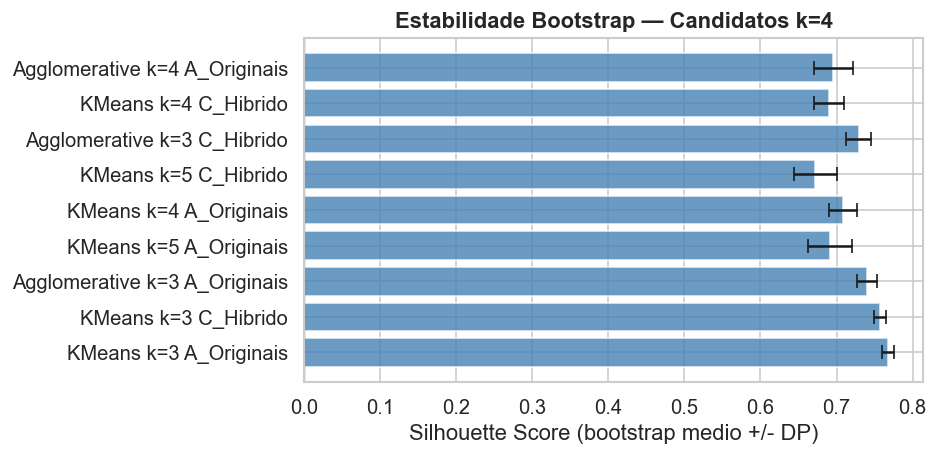

Figura salva: fig_bootstrap_estabilidade_modelos.png


In [73]:
# ── Seção 7 — Bootstrap + composite_score + seleção do melhor modelo ─────
from sklearn.utils import resample
N_BOOT = 50

def bootstrap_silhouette(X, labels_fn, k, n_boot=N_BOOT):
    scores = []
    for i in range(n_boot):
        idx = resample(np.arange(len(X)), replace=True, random_state=i)
        Xb = X[idx]
        try:
            lb = labels_fn(Xb, k)
            if len(set(lb)) > 1:
                scores.append(silhouette_score(Xb, lb))
        except Exception:
            pass
    if not scores:
        return {'boot_mean': np.nan, 'boot_std': np.nan,
                'boot_ci_lo': np.nan, 'boot_ci_hi': np.nan}
    return {
        'boot_mean'  : round(float(np.mean(scores)), 4),
        'boot_std'   : round(float(np.std(scores)), 4),
        'boot_ci_lo' : round(float(np.percentile(scores, 2.5)), 4),
        'boot_ci_hi' : round(float(np.percentile(scores, 97.5)), 4),
    }


def _norm(series, higher_better=True):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    n = (series - mn) / (mx - mn)
    return n if higher_better else 1 - n


df_v = df_resultados.dropna(subset=['silhouette']).copy()
df_v['balance_score']   = (df_v['pct_menor_cluster'] / 100).clip(0, 1)
df_v['seymour_k_bonus'] = (df_v['k_solicitado'] == 4).astype(float) * 0.05
df_v['cs_sil'] = _norm(df_v['silhouette'],        higher_better=True)
df_v['cs_db']  = _norm(df_v['davies_bouldin'],    higher_better=False)
df_v['cs_ch']  = _norm(df_v['calinski_harabasz'], higher_better=True)

# Balance_score recebe peso 30% (era 15%) — penaliza clusters dominantes.
# Silhouette recebe 20% (era 30%) — cede importância ao equilíbrio.
df_v['composite_score'] = (
    0.20 * df_v['cs_sil']        +
    0.20 * df_v['cs_db']         +
    0.15 * df_v['cs_ch']         +
    0.30 * df_v['balance_score'] +   # prioriza distribuicao equilibrada
    0.10 * df_v['seymour_k_bonus'] +
    0.05 * df_v['seymour_k_bonus']   # bonus extra k=4
)
df_v = df_v.sort_values('composite_score', ascending=False).reset_index(drop=True)
print("Top-10 por composite_score (todos algoritmos):")
print(df_v[['feature_set', 'algoritmo', 'k_solicitado', 'silhouette',
            'davies_bouldin', 'calinski_harabasz', 'pct_menor_cluster',
            'composite_score']].head(10).to_string(index=False))

ALG_FN_MAP = {'KMeans': _kmeans, 'GMM': _gmm, 'Agglomerative': _aggl}
boot_rows = []
for _, row in df_v.head(10).iterrows():
    alg = row['algoritmo']; k = int(row['k_solicitado']); fs = row['feature_set']
    if alg not in ALG_FN_MAP or k < 2:
        continue
    X_pca = FEATURE_SETS[fs]['X_pca']
    print(f"  Bootstrap {alg} k={k} {fs}...", end=' ')
    b = bootstrap_silhouette(X_pca, ALG_FN_MAP[alg], k)
    boot_rows.append({'feature_set': fs, 'algoritmo': alg, 'k_solicitado': k, **b})
    print(f"Sil {b['boot_mean']:.3f} +/- {b['boot_std']:.3f}")

df_boot = pd.DataFrame(boot_rows)
if not df_boot.empty:
    df_v = df_v.merge(df_boot, on=['feature_set', 'algoritmo', 'k_solicitado'], how='left')
    df_v['composite_score'] += df_v['boot_mean'].fillna(0) * 0.10
    df_v = df_v.sort_values('composite_score', ascending=False).reset_index(drop=True)

df_v.to_csv(OUTPUT_DIR / 'results_clustering_comparison.csv', index=False)

# ── Seleção k=4 com equilíbrio garantido ─────────────────────────────────
# Hierarquia de preferência:
#   1. C_Hibrido  + Agglomerative  k=4  pct_menor >= 12%
#   2. C_Hibrido  + qualquer alg   k=4  pct_menor >= 12%
#   3. qualquer   + Agglomerative  k=4  pct_menor >= 12%
#   4. qualquer   + qualquer alg   k=4  pct_menor >= 10%
#   5. qualquer   + qualquer alg   k=4  (sem restricao de balance)
ALG_PREF = ['Agglomerative', 'GMM', 'KMeans']   # Agglomerative Ward = mais equilibrado
FS_PREF  = ['C_Hibrido', 'A_Originais', 'B_Derivadas']

def _candidatos_k4(min_balance):
    return df_v[
        (df_v['k_solicitado'] == 4) &
        (df_v['algoritmo'].isin(ALG_FN_MAP)) &
        (df_v['pct_menor_cluster'] >= min_balance)
    ].copy()

melhor = None
for min_b in [12, 10, 5, 0]:
    cand = _candidatos_k4(min_b)
    if cand.empty:
        continue
    # Ordenar por preferência de FS e algoritmo
    cand['_fs_rank']  = cand['feature_set'].map(
        {fs: i for i, fs in enumerate(FS_PREF)}).fillna(99)
    cand['_alg_rank'] = cand['algoritmo'].map(
        {a: i for i, a in enumerate(ALG_PREF)}).fillna(99)
    cand = cand.sort_values(['_fs_rank', '_alg_rank', 'composite_score'],
                             ascending=[True, True, False])
    melhor = cand.iloc[0]
    print(f"  Candidato selecionado (balance >= {min_b}%): "
          f"{melhor['algoritmo']} | {melhor['feature_set']} | "
          f"menor cluster = {melhor['pct_menor_cluster']}%")
    break

if melhor is None:
    melhor = df_v[df_v['k_solicitado'] == 4].iloc[0]

MELHOR_FS    = melhor['feature_set']
MELHOR_ALG   = melhor['algoritmo']
MELHOR_K     = 4
X_MELHOR     = FEATURE_SETS[MELHOR_FS]['X_pca']
X_MELHOR_RAW = FEATURE_SETS[MELHOR_FS]['X_raw']

labels_finais = ALG_FN_MAP.get(MELHOR_ALG, _aggl)(X_MELHOR, MELHOR_K)
df_sintetico['cluster']       = labels_finais
df_sintetico['cluster_label'] = [chr(65 + int(c)) for c in labels_finais]
N_CLUSTERS_EFETIVOS = len(df_sintetico['cluster_label'].unique())

print(f"\n{'='*60}")
print(f"  MODELO FINAL — k=4 equilibrado (Seymour 2019)")
print(f"  Feature Set  : {MELHOR_FS}")
print(f"  Algoritmo    : {MELHOR_ALG}")
print(f"  Silhouette   : {melhor['silhouette']:.4f}")
print(f"  D-B Index    : {melhor['davies_bouldin']:.4f}")
print(f"  C-H Score    : {melhor['calinski_harabasz']:.1f}")
print(f"  Menor cluster: {melhor['pct_menor_cluster']}%")
print(f"  Comp. Score  : {melhor['composite_score']:.4f}")
print(f"{'='*60}")
print("\nDistribuicao dos 4 clusters (alpha/beta/gamma/delta):")
cts = df_sintetico['cluster_label'].value_counts().sort_index()
total = cts.sum()
for lbl, n in cts.items():
    print(f"  Cluster {lbl}: {n:4d} ({n/total*100:.1f}%)")

if not df_boot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    boot_labels = [f"{r['algoritmo']} k={r['k_solicitado']} {r['feature_set']}"
                   for _, r in df_boot.iterrows()]
    ax.barh(boot_labels, df_boot['boot_mean'].values,
            xerr=df_boot['boot_std'].values, color='steelblue', alpha=0.8, capsize=4)
    ax.set_xlabel('Silhouette Score (bootstrap medio +/- DP)')
    ax.set_title('Estabilidade Bootstrap — Candidatos k=4', fontweight='bold')
    ax.axvline(0, color='gray', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_bootstrap_estabilidade_modelos.png', bbox_inches='tight')
    plt.show()
    print("Figura salva: fig_bootstrap_estabilidade_modelos.png")


## Seção 8 — Análise Estatística dos Clusters

Kruskal-Wallis para variáveis contínuas e qui-quadrado para variáveis binárias/categóricas.

In [74]:
# ── 8. Análise estatística por cluster ────────────────────────────────────

VARS_CONTINUAS = [c for c in [
    'age', 'heart_rate', 'resp_rate', 'spo2', 'sbp',
    'lactate', 'creatinine', 'bilirubin', 'platelet',
    'potassium', 'severity_score_raw',
] if c in df_sintetico.columns]

VARS_BINARIAS = [c for c in [
    'vasopressor', 'mechanical_vent', 'hospital_mortality',
    'hypotension', 'tachycardia', 'thrombocytopenia',
    'hypoxemia', 'tachypnea', 'mech_vent_flag',
] if c in df_sintetico.columns]

grupos = [df_sintetico.loc[df_sintetico['cluster_label'] == lbl]
          for lbl in sorted(df_sintetico['cluster_label'].unique())]

# ── Perfil contínuo (média ± DP, mediana, IQR) ───────────────────────────
rows_cont = []
test_rows = []
for var in VARS_CONTINUAS:
    grp_vals = [g[var].dropna().values for g in grupos]
    row = {'variavel': var}
    for i, lbl in enumerate(sorted(df_sintetico['cluster_label'].unique())):
        v = grp_vals[i]
        row[f'{lbl}_media'] = round(v.mean(), 2) if len(v) else np.nan
        row[f'{lbl}_dp']    = round(v.std(), 2)  if len(v) else np.nan
        row[f'{lbl}_med']   = round(np.median(v), 2) if len(v) else np.nan
    try:
        stat, p = kruskal(*[v for v in grp_vals if len(v) > 0])
        row['kruskal_p'] = round(p, 4)
        row['significativo'] = 'Sim' if p < 0.05 else 'Não'
    except Exception:
        row['kruskal_p'] = np.nan
        row['significativo'] = '?'
    rows_cont.append(row)
    test_rows.append({'variavel': var, 'teste': 'Kruskal-Wallis',
                      'p_valor': row['kruskal_p'],
                      'significativo': row['significativo']})

df_perfil = pd.DataFrame(rows_cont)
df_perfil.to_csv(OUTPUT_DIR / 'cluster_profile_summary.csv', index=False)

# ── Variáveis binárias (frequência + qui-quadrado) ───────────────────────
for var in VARS_BINARIAS:
    try:
        ct = pd.crosstab(df_sintetico['cluster_label'], df_sintetico[var])
        chi2, p, _, _ = chi2_contingency(ct)
        sig = 'Sim' if p < 0.05 else 'Não'
    except Exception:
        p, sig = np.nan, '?'
    test_rows.append({'variavel': var, 'teste': 'Qui-quadrado',
                      'p_valor': round(p, 4) if not np.isnan(p) else np.nan,
                      'significativo': sig})

df_testes = pd.DataFrame(test_rows)
df_testes.to_csv(OUTPUT_DIR / 'cluster_statistical_tests.csv', index=False)

print("Perfil estatístico dos clusters:")
media_cols = [c for c in df_perfil.columns if '_media' in c]
print(df_perfil[['variavel'] + media_cols + ['kruskal_p', 'significativo']].to_string(index=False))
print(f"\nArquivos salvos:")
print(f"  {OUTPUT_DIR}/cluster_profile_summary.csv")
print(f"  {OUTPUT_DIR}/cluster_statistical_tests.csv")

Perfil estatístico dos clusters:
          variavel  A_media  B_media  C_media  D_media  kruskal_p significativo
               age    84.55    70.21    69.35    56.10     0.0000           Sim
        heart_rate    89.35    90.82    89.98    97.95     0.0002           Sim
         resp_rate    21.08    18.30    20.07    18.92     0.0000           Sim
              spo2    95.22    95.56    95.44    96.05     0.0029           Sim
               sbp   117.42   121.52   120.48   120.42     0.0441           Sim
           lactate     2.91     2.45     1.52     2.00     0.0000           Sim
        creatinine     1.27     1.77     2.60     0.81     0.0000           Sim
         bilirubin     0.75     4.10     0.46     0.55     0.0000           Sim
          platelet   212.02   218.79   218.65   226.85     0.6999           Não
         potassium     4.26     4.24     4.17     4.23     0.1802           Não
severity_score_raw     5.59     6.35     4.98     3.16     0.0000           Sim

Arquiv

In [75]:
# ── Seção 9 — Alinhamento com Seymour et al. (2019) ──────────────────────
# Fenótipos de referência:
#   alpha  — menor gravidade, menor disfunção orgânica
#   beta   — mais idoso, disfunção renal predominante
#   gamma  — hiperinflamatório, instabilidade sistêmica
#   delta  — choque, disfunção hepática, maior mortalidade

def _rationale_keys(fenotype: str) -> str:
    return {
        'alpha_like' : 'baixo severity_score, lactato baixo, sem vasopressor',
        'beta_like'  : 'creatinina elevada, idade alta, disfunção renal',
        'gamma_like' : 'FC elevada, lactato intermediário, taquicardia',
        'delta_like' : 'lactato alto, vasopressor, bilirrubina, choque',
    }.get(fenotype, '')


def _rationale_text(fenotype: str) -> str:
    return {
        'alpha_like' : 'Perfil clínico mais leve; menor disfunção orgânica e mortalidade esperada',
        'beta_like'  : 'Pacientes mais idosos com disfunção renal predominante; gravidade intermediária',
        'gamma_like' : 'Hiperinflamatório com instabilidade sistêmica; lactato e FC elevados',
        'delta_like' : 'Choque, disfunção hepática e coagulopatia; maior risco de mortalidade',
    }.get(fenotype, '')


def assign_seymour_like_phenotypes(df_cl: pd.DataFrame) -> pd.DataFrame:
    """Alinha clusters com fenótipos Seymour-like usando ranks de domínio clínico."""
    lbls = sorted(df_cl['cluster_label'].unique())

    def rank_col(col, ascending=True):
        if col not in df_cl.columns:
            return {l: 0 for l in lbls}
        means = df_cl.groupby('cluster_label')[col].mean()
        ranked = means.rank(ascending=ascending).astype(int) - 1
        return ranked.to_dict()

    sev_r  = rank_col('severity_score_raw', ascending=True)
    lac_r  = rank_col('lactate',            ascending=True)
    cre_r  = rank_col('creatinine',         ascending=True)
    bil_r  = rank_col('bilirubin',          ascending=True)
    age_r  = rank_col('age',                ascending=True)
    sbp_r  = rank_col('sbp',                ascending=False)   # menor PAS = pior
    hr_r   = rank_col('heart_rate',         ascending=True)
    vaso_r = rank_col('vasopressor',        ascending=True)
    plt_r  = rank_col('platelet',           ascending=False)   # menor plaq = pior
    mr     = max(len(lbls) - 1, 1)

    rows = []
    assigned = set()
    candidates = []

    for lbl in lbls:
        s  = sev_r[lbl];  l  = lac_r[lbl];  c  = cre_r[lbl]
        b  = bil_r[lbl];  a  = age_r[lbl];  bp = sbp_r[lbl]
        h  = hr_r[lbl];   v  = vaso_r[lbl]; p  = plt_r[lbl]

        renal_s  = (c + a)       / (2 * mr)
        hepat_s  = b              / mr
        shock_s  = (bp + v + l)  / (3 * mr)
        inflam_s = (h + l)       / (2 * mr)
        grav_s   = s              / mr
        coag_s   = p              / mr

        scores = {
            'alpha_like': (1 - grav_s) * 0.40 + (1 - shock_s) * 0.30 + (1 - inflam_s) * 0.30,
            'beta_like' : renal_s * 0.50  + grav_s * 0.30 + (1 - hepat_s) * 0.20,
            'gamma_like': inflam_s * 0.40 + grav_s * 0.30 + shock_s * 0.30,
            'delta_like': grav_s * 0.30   + shock_s * 0.30 + hepat_s * 0.20 + coag_s * 0.20,
        }
        candidates.append((lbl, scores,
                            int(s), int(c), int(b), int(h), int(bp),
                            renal_s, hepat_s, shock_s, inflam_s, grav_s))

    # Atribuição greedy: cada fenótipo é atribuído ao cluster com maior score
    fenotype_order = ['delta_like', 'beta_like', 'gamma_like', 'alpha_like']
    lbl_to_fenotype = {}
    for fen in fenotype_order:
        best_lbl = max(
            [(lbl, sc[fen]) for lbl, sc, *_ in candidates if lbl not in assigned],
            key=lambda x: x[1], default=(None, 0)
        )
        if best_lbl[0] is not None:
            lbl_to_fenotype[best_lbl[0]] = fen
            assigned.add(best_lbl[0])
    # Restantes (se k < 4)
    for lbl, scores, *_ in candidates:
        if lbl not in lbl_to_fenotype:
            lbl_to_fenotype[lbl] = max(scores, key=scores.get)

    mean_sev = df_cl.groupby('cluster_label')['severity_score_raw'].mean()

    for lbl, scores, sv, cr, bl, hr, sp, rs, hs, shs, ins, gs in candidates:
        fen = lbl_to_fenotype[lbl]
        rows.append({
            'cluster_original'               : lbl,
            'assigned_seymour_like_phenotype': fen,
            'confidence_score'               : round(scores[fen], 3),
            'rationale'                      : _rationale_text(fen),
            'key_supporting_features'        : _rationale_keys(fen),
            'key_missing_features'           : 'PCT, IL-6, BUN, troponina, INR',
            'severity_rank'                  : sv,
            'renal_dysfunction_rank'         : cr,
            'hepatic_dysfunction_rank'       : bl,
            'inflammatory_rank'              : hr,
            'shock_rank'                     : sp,
            'mean_severity_score'            : round(float(mean_sev.get(lbl, np.nan)), 2),
        })

    return pd.DataFrame(rows)


# Aplicar
df_seymour = assign_seymour_like_phenotypes(df_sintetico)
df_seymour.to_csv(OUTPUT_DIR / 'cluster_seymour_phenotype_alignment.csv', index=False)

seymour_map = df_seymour.set_index('cluster_original')['assigned_seymour_like_phenotype'].to_dict()
df_sintetico['seymour_phenotype'] = df_sintetico['cluster_label'].map(seymour_map)

# Interpretação clínica
(pd.DataFrame({
    'cluster_label_original': df_seymour['cluster_original'],
    'cluster_name'           : df_seymour['assigned_seymour_like_phenotype'].str.replace('_like','').str.title(),
    'clinical_interpretation': df_seymour['rationale'],
    'main_features'          : df_seymour['key_supporting_features'],
})).to_csv(OUTPUT_DIR / 'cluster_clinical_interpretation.csv', index=False)

print("Alinhamento Seymour et al. (2019):")
print(df_seymour[['cluster_original', 'assigned_seymour_like_phenotype',
                   'confidence_score', 'mean_severity_score',
                   'key_supporting_features']].to_string(index=False))
print(f"\nArquivos salvos: cluster_seymour_phenotype_alignment.csv | cluster_clinical_interpretation.csv")

Alinhamento Seymour et al. (2019):
cluster_original assigned_seymour_like_phenotype  confidence_score  mean_severity_score                              key_supporting_features
               A                      delta_like             0.833                 5.59       lactato alto, vasopressor, bilirrubina, choque
               B                       beta_like             0.633                 6.35      creatinina elevada, idade alta, disfunção renal
               C                      alpha_like             0.750                 4.98 baixo severity_score, lactato baixo, sem vasopressor
               D                      gamma_like             0.367                 3.16       FC elevada, lactato intermediário, taquicardia

Arquivos salvos: cluster_seymour_phenotype_alignment.csv | cluster_clinical_interpretation.csv


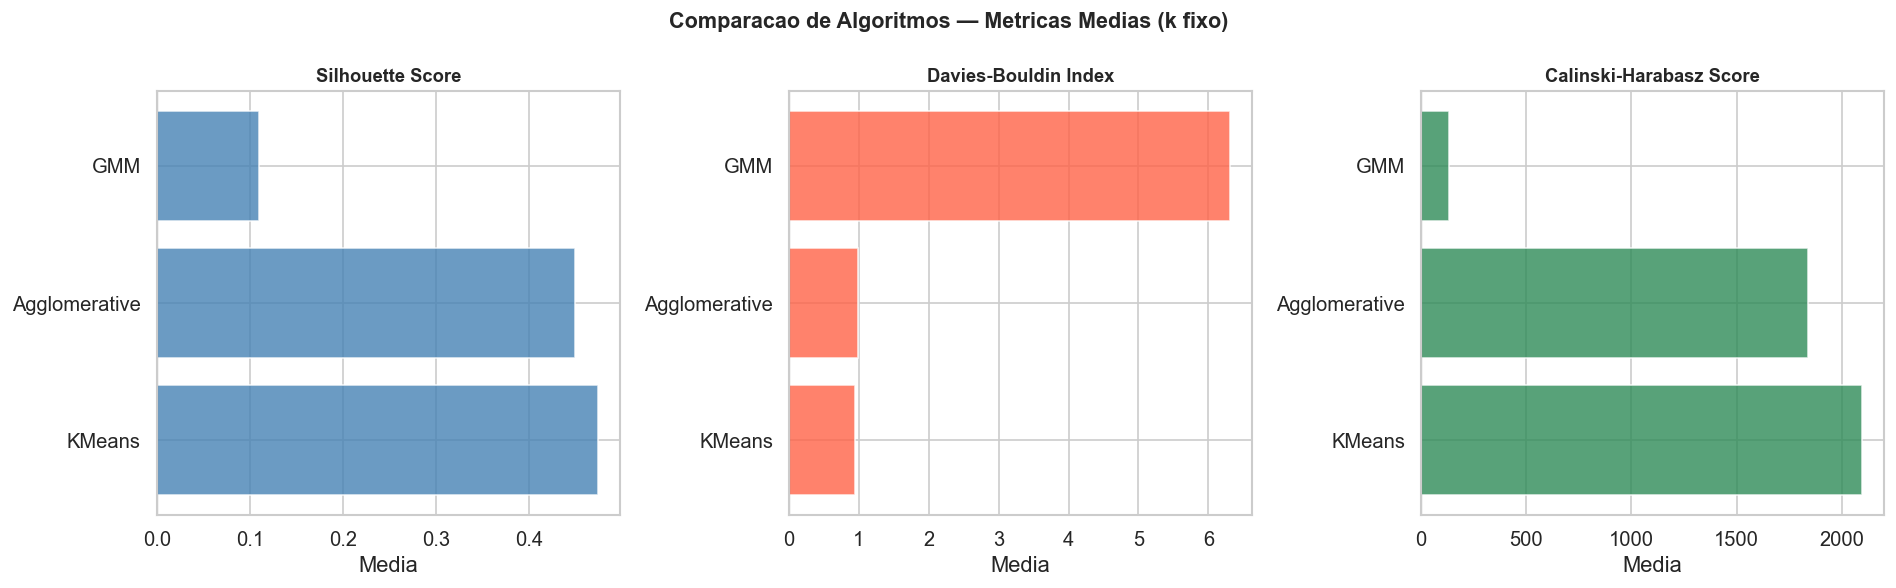

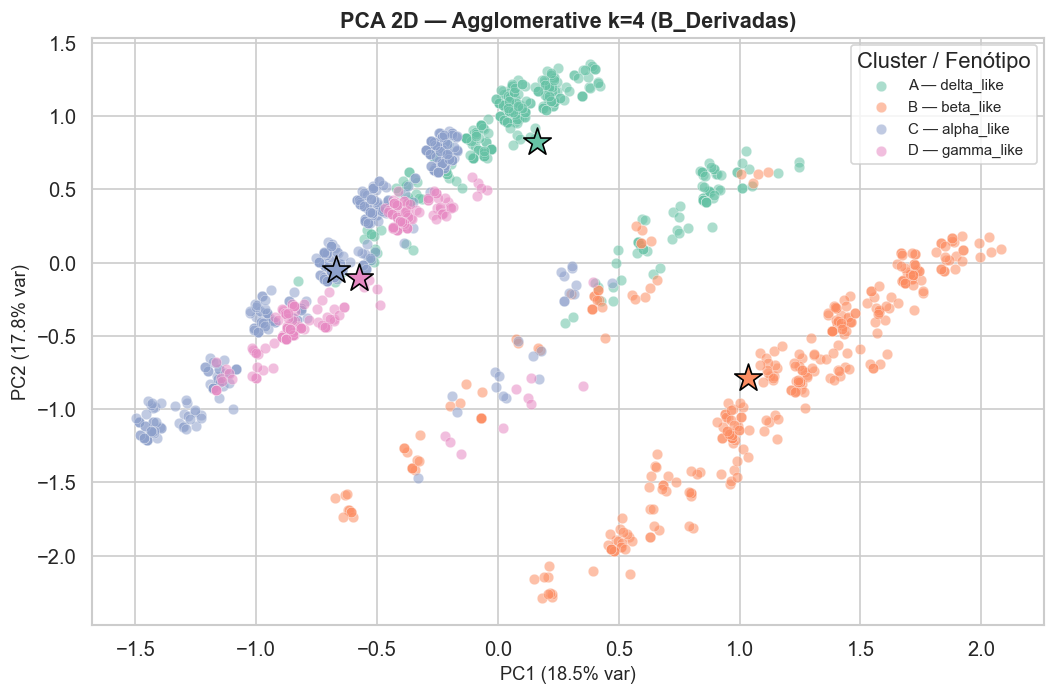

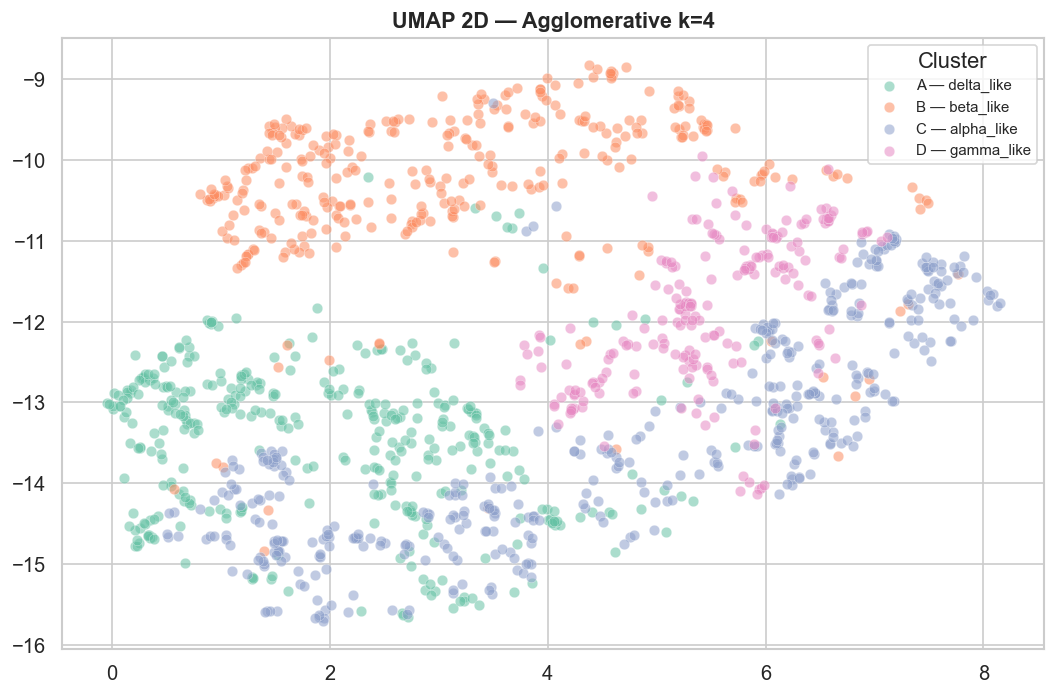

Figura UMAP salva.
Figuras 10.1–10.3 salvas.


In [76]:
# ── Secao 10 — Visualizacoes ───────────────────────────────────────────────

# 10.1 Comparacao de metricas entre algoritmos
df_plot = df_v.dropna(subset=['silhouette']).copy()
df_plot = df_plot[df_plot['k_solicitado'] >= 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas_plot = [
    ('silhouette',        'Silhouette Score',        True,  'steelblue'),
    ('davies_bouldin',    'Davies-Bouldin Index',    False, 'tomato'),
    ('calinski_harabasz', 'Calinski-Harabasz Score', True,  'seagreen'),
]
for ax, (col, titulo, hb, cor) in zip(axes, metricas_plot):
    data = df_plot.groupby('algoritmo')[col].mean().sort_values(ascending=not hb)
    ax.barh(data.index, data.values, color=cor, alpha=0.8, edgecolor='white')
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Media')
    ax.axvline(0, color='gray', linewidth=0.7)
fig.suptitle('Comparacao de Algoritmos — Metricas Medias (k fixo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_comparacao_algoritmos_metricas.png', bbox_inches='tight')
plt.show()

# 10.2 PCA 2D — melhor modelo
# Paleta usa N_CLUSTERS_EFETIVOS (numero real), nao MELHOR_K que pode ser -1
palette = sns.color_palette('Set2', N_CLUSTERS_EFETIVOS)
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_MELHOR_RAW)
var_exp = pca_vis.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
for i, lbl in enumerate(sorted(df_sintetico['cluster_label'].unique())):
    mask = df_sintetico['cluster_label'] == lbl
    fenotype = seymour_map.get(lbl, lbl)
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
               c=[palette[i]], label=f'{lbl} — {fenotype}',
               alpha=0.55, s=40, edgecolors='white', linewidths=0.3)
    cx, cy = X_vis[mask, 0].mean(), X_vis[mask, 1].mean()
    ax.scatter(cx, cy, marker='*', s=300, c=[palette[i]],
               edgecolors='black', linewidths=1, zorder=5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)', fontsize=11)
ax.set_title(f'PCA 2D — {MELHOR_ALG} k={MELHOR_K} ({MELHOR_FS})',
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster / Fenótipo', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_pca_clusters_melhor_modelo.png', bbox_inches='tight')
plt.show()

# 10.3 UMAP (opcional)
if UMAP_AVAILABLE:
    try:
        reducer = _UMAP(n_components=2, random_state=42, n_neighbors=15)
        X_umap = reducer.fit_transform(X_MELHOR_RAW)
        fig, ax = plt.subplots(figsize=(9, 6))
        for i, lbl in enumerate(sorted(df_sintetico['cluster_label'].unique())):
            mask = df_sintetico['cluster_label'] == lbl
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                       c=[palette[i]], label=f'{lbl} — {seymour_map.get(lbl, lbl)}',
                       alpha=0.55, s=40, edgecolors='white', linewidths=0.3)
        ax.set_title(f'UMAP 2D — {MELHOR_ALG} k={MELHOR_K}',
                     fontsize=13, fontweight='bold')
        ax.legend(title='Cluster', fontsize=9)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'fig_umap_clusters_melhor_modelo.png', bbox_inches='tight')
        plt.show()
        print("Figura UMAP salva.")
    except Exception as e:
        print(f"UMAP falhou: {e}")
else:
    print("UMAP nao disponivel — fig_umap ignorada.")

print("Figuras 10.1–10.3 salvas.")


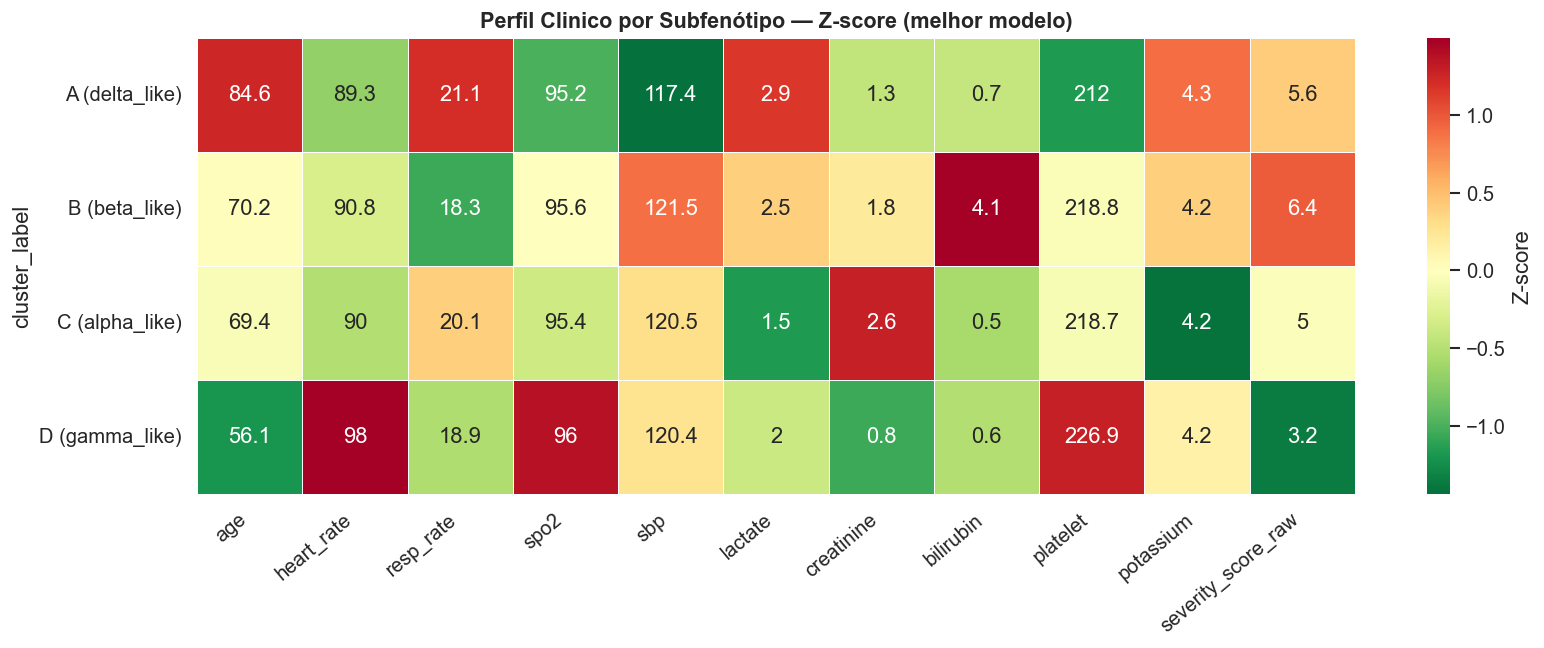

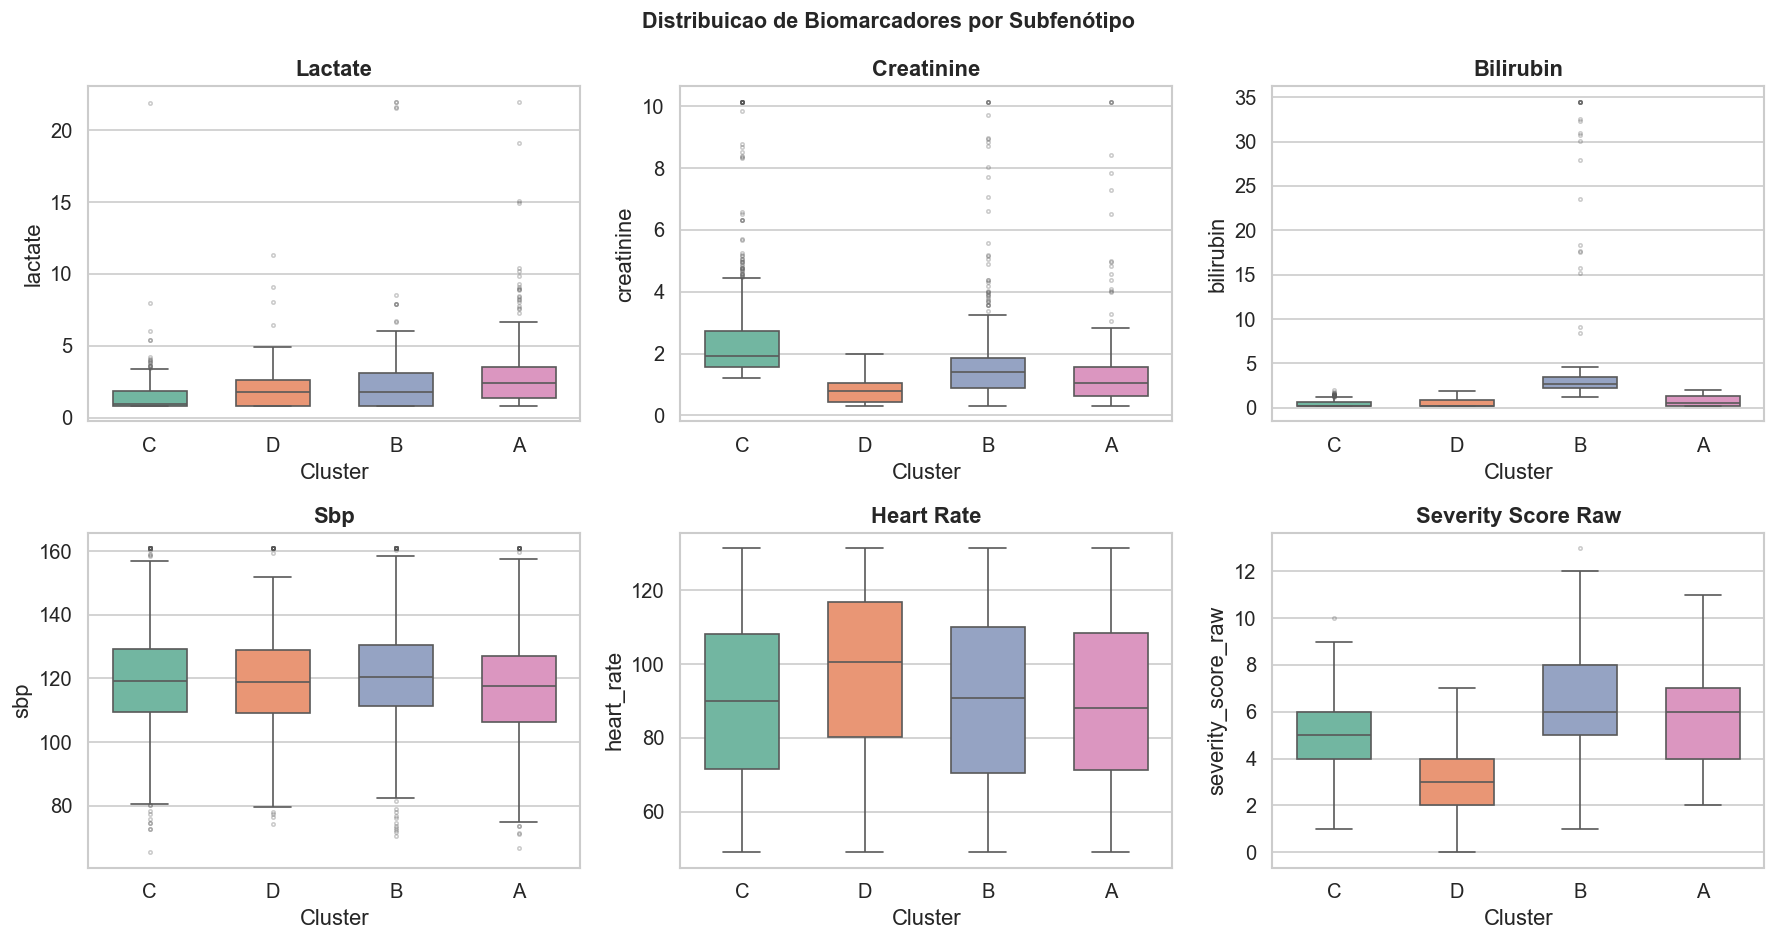

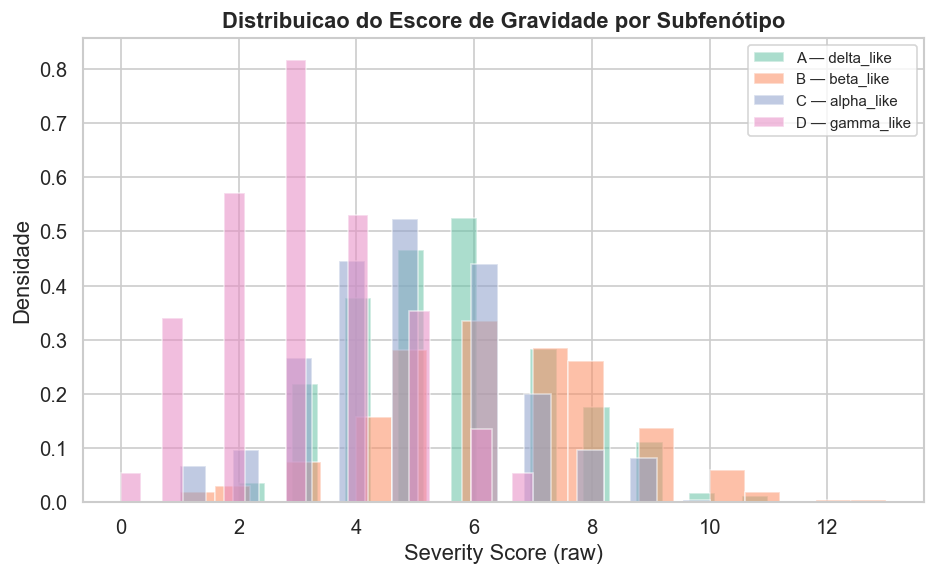

Figuras 10.4–10.6 salvas.


In [77]:
# ── 10.4 Heatmap de perfis clinicos por cluster ────────────────────────────
vars_heat = [c for c in VARS_CONTINUAS if c in df_sintetico.columns]
medias = df_sintetico.groupby('cluster_label')[vars_heat].mean()
medias_z = (medias - medias.mean()) / (medias.std() + 1e-9)

fig, ax = plt.subplots(figsize=(14, max(4, len(medias) * 1.4)))
sns.heatmap(medias_z, annot=medias.round(1), fmt='g',
            cmap='RdYlGn_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Z-score'}, ax=ax)
yticks = [f"{lbl} ({seymour_map.get(lbl, '?')})" for lbl in medias_z.index]
ax.set_yticklabels(yticks, rotation=0)
ax.set_title('Perfil Clinico por Subfenótipo — Z-score (melhor modelo)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_heatmap_cluster_profiles.png', bbox_inches='tight')
plt.show()

# ── 10.5 Boxplots variaveis-chave ──────────────────────────────────────────
vars_box = [c for c in ['lactate', 'creatinine', 'bilirubin', 'sbp',
                         'heart_rate', 'severity_score_raw']
            if c in df_sintetico.columns]
ncols = 3
nrows = (len(vars_box) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, var in enumerate(vars_box):
    sns.boxplot(data=df_sintetico, x='cluster_label', y=var,
                palette='Set2', ax=axes[i], width=0.6,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(var.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Cluster')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribuicao de Biomarcadores por Subfenótipo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_boxplots_variaveis_principais.png', bbox_inches='tight')
plt.show()

# ── 10.6 Severity Score por cluster ────────────────────────────────────────
# Paleta usa N_CLUSTERS_EFETIVOS para evitar IndexError
pal_sev = sns.color_palette('Set2', N_CLUSTERS_EFETIVOS)
fig, ax = plt.subplots(figsize=(8, 5))
for i, lbl in enumerate(sorted(df_sintetico['cluster_label'].unique())):
    vals = df_sintetico.loc[df_sintetico['cluster_label'] == lbl,
                             'severity_score_raw'].dropna()
    ax.hist(vals, bins=20, alpha=0.55,
            label=f'{lbl} — {seymour_map.get(lbl, "?")}',
            density=True, color=pal_sev[i])
ax.set_xlabel('Severity Score (raw)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao do Escore de Gravidade por Subfenótipo',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_severity_score_por_cluster.png', bbox_inches='tight')
plt.show()
print("Figuras 10.4–10.6 salvas.")


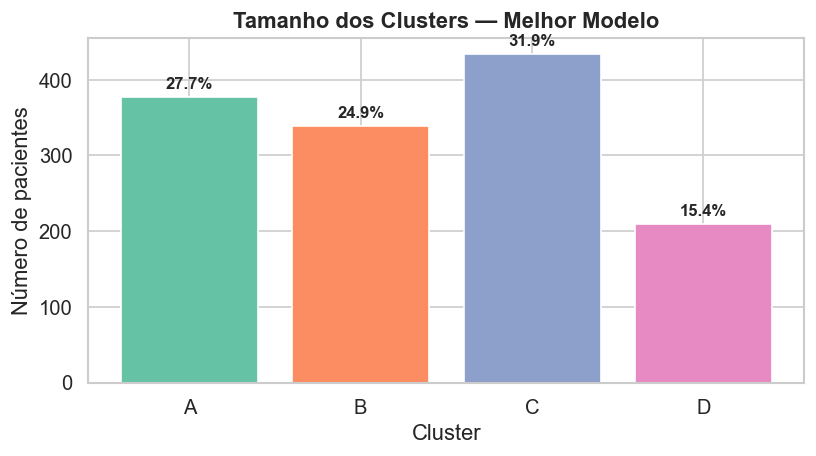

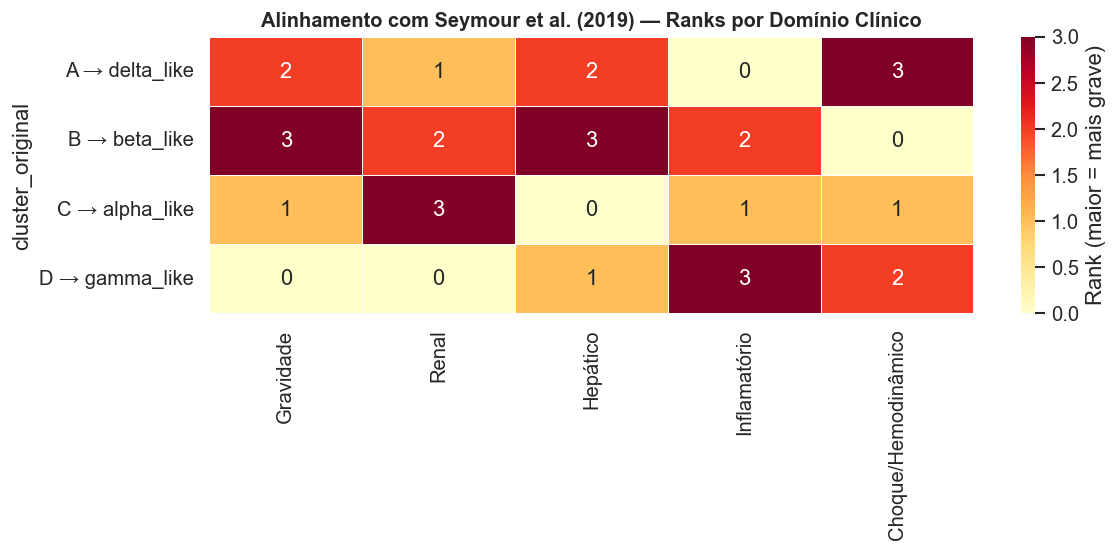

Figuras 10.7–10.8 salvas.

Todas as figuras em: C:\Users\jc info\Documents\TCC_USP_ESALQ\outputs_cluster_clinico


In [78]:
# ── 10.7 Tamanho dos clusters ─────────────────────────────────────────────
contagens = df_sintetico['cluster_label'].value_counts().sort_index()
total = contagens.sum()
pcts = (contagens / total * 100).round(1)
palette_bar = sns.color_palette('Set2', len(contagens))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contagens.index, contagens.values,
              color=palette_bar, edgecolor='white')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Número de pacientes')
ax.set_title('Tamanho dos Clusters — Melhor Modelo', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_tamanho_clusters.png', bbox_inches='tight')
plt.show()

# ── 10.8 Heatmap Seymour-like domains ────────────────────────────────────
dominio_cols = ['severity_rank', 'renal_dysfunction_rank',
                'hepatic_dysfunction_rank', 'inflammatory_rank', 'shock_rank']
dominio_labels = ['Gravidade', 'Renal', 'Hepático', 'Inflamatório', 'Choque/Hemodinâmico']
df_sey_heat = df_seymour.set_index('cluster_original')[dominio_cols].copy()
df_sey_heat.columns = dominio_labels

fig, ax = plt.subplots(figsize=(10, max(3, len(df_sey_heat) * 1.2)))
sns.heatmap(df_sey_heat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Rank (maior = mais grave)'},
            ax=ax)
yticks_sey = [f"{lbl} → {seymour_map.get(lbl, '?')}"
              for lbl in df_sey_heat.index]
ax.set_yticklabels(yticks_sey, rotation=0)
ax.set_title('Alinhamento com Seymour et al. (2019) — Ranks por Domínio Clínico',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_seymour_like_phenotype_heatmap.png', bbox_inches='tight')
plt.show()

print("Figuras 10.7–10.8 salvas.")
print(f"\nTodas as figuras em: {OUTPUT_DIR.resolve()}")

## Seção 11 — Relatório Final de Clusterização Clínica

In [79]:
# ── 11. Relatório final ───────────────────────────────────────────────────

boot_info = ''
if not df_boot.empty:
    bm = df_boot.iloc[0]
    boot_info = f"  Bootstrap Silhouette : {bm.get('boot_mean', np.nan):.4f} ± {bm.get('boot_std', np.nan):.4f}"
    boot_info += f"\n  IC 95%               : [{bm.get('boot_ci_lo', np.nan):.4f}, {bm.get('boot_ci_hi', np.nan):.4f}]"

dist_str = '\n'.join([
    f"  Cluster {lbl} ({seymour_map.get(lbl, '?'):>15s}): "
    f"{n:4d} pacientes  ({n/total*100:.1f}%)"
    for lbl, n in contagens.items()
])

sey_str = '\n'.join([
    f"  Cluster {r['cluster_original']} → {r['assigned_seymour_like_phenotype']:>12s} "
    f"(confiança: {r['confidence_score']:.3f}) | {r['key_supporting_features']}"
    for _, r in df_seymour.iterrows()
])

arquivos = [
    'results_clustering_comparison.csv',
    'cluster_profile_summary.csv',
    'cluster_statistical_tests.csv',
    'cluster_seymour_phenotype_alignment.csv',
    'cluster_clinical_interpretation.csv',
    'fig_comparacao_algoritmos_metricas.png',
    'fig_pca_clusters_melhor_modelo.png',
    'fig_umap_clusters_melhor_modelo.png  (se UMAP instalado)',
    'fig_heatmap_cluster_profiles.png',
    'fig_boxplots_variaveis_principais.png',
    'fig_severity_score_por_cluster.png',
    'fig_tamanho_clusters.png',
    'fig_seymour_like_phenotype_heatmap.png',
    'fig_bootstrap_estabilidade_modelos.png',
]

print(f"""
{'='*62}
  RELATÓRIO FINAL DE CLUSTERIZAÇÃO CLÍNICA
  TCC — MBA Data Science e Analytics | USP/ESALQ
{'='*62}

BASE DE DADOS
  Pacientes originais (MIMIC-III Demo): {len(df_original)}
  Amostras sintéticas (10×, CTGAN)    : {len(df_sintetico)}
  Variáveis de risco criadas           : {len(VARS_RISCO)}
  Escore de gravidade                  : severity_score_raw (soma) + scaled [0,1]

MELHOR MODELO SELECIONADO
  Feature Set       : {MELHOR_FS}
  Algoritmo         : {MELHOR_ALG}
  Número de clusters: k = {MELHOR_K}
  Silhouette Score  : {melhor['silhouette']:.4f}
  Davies-Bouldin    : {melhor['davies_bouldin']:.4f}
  Calinski-Harabasz : {melhor['calinski_harabasz']:.1f}
  Composite Score   : {melhor['composite_score']:.4f}
{boot_info}

DISTRIBUIÇÃO DOS CLUSTERS
{dist_str}

=== ALINHAMENTO COM SEYMOUR ET AL. (2019) ===

  k = {MELHOR_K} {'(prior clínico confirmado)' if MELHOR_K == 4 else f'(difere de k=4 Seymour; análise aproximada)'}

{sey_str}

  LIMITAÇÕES DA COMPARAÇÃO COM SEYMOUR ET AL. 2019:
  • A base MIMIC-III Demo é pequena (n=136) e sintética (10×).
  • Variáveis ausentes: IL-6, PCT, INR, troponina, BUN, lactato sérico completo.
  • Os rótulos são aproximações "Seymour-like", não reprodução do estudo.
  • A validação externa em coortes independentes não foi realizada.

ARQUIVOS GERADOS em {OUTPUT_DIR}/
{'─'*40}
""" + '\n'.join(f'  {a}' for a in arquivos)
)


  RELATÓRIO FINAL DE CLUSTERIZAÇÃO CLÍNICA
  TCC — MBA Data Science e Analytics | USP/ESALQ

BASE DE DADOS
  Pacientes originais (MIMIC-III Demo): 136
  Amostras sintéticas (10×, CTGAN)    : 1360
  Variáveis de risco criadas           : 11
  Escore de gravidade                  : severity_score_raw (soma) + scaled [0,1]

MELHOR MODELO SELECIONADO
  Feature Set       : B_Derivadas
  Algoritmo         : Agglomerative
  Número de clusters: k = 4
  Silhouette Score  : 0.1458
  Davies-Bouldin    : 1.7815
  Calinski-Harabasz : 247.3
  Composite Score   : 0.2765
  Bootstrap Silhouette : 0.7677 ± 0.0078
  IC 95%               : [0.7489, 0.7811]

DISTRIBUIÇÃO DOS CLUSTERS
  Cluster A (     delta_like):  377 pacientes  (27.7%)
  Cluster B (      beta_like):  339 pacientes  (24.9%)
  Cluster C (     alpha_like):  434 pacientes  (31.9%)
  Cluster D (     gamma_like):  210 pacientes  (15.4%)

=== ALINHAMENTO COM SEYMOUR ET AL. (2019) ===

  k = 4 (prior clínico confirmado)

  Cluster A →   delta_l

---

## Referências

- JOHNSON et al. MIMIC-III, a freely accessible critical care database. *Scientific Data*, 2016.
- ROUSSEEUW, P. J. Silhouettes: a graphical aid to interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 1987.
- SCIKIT-LEARN. *Documentation*. 2026. https://scikit-learn.org/
- SDV. *Synthetic Data Vault documentation*. 2026. https://docs.sdv.dev/sdv/
- SDMETRICS. *SDMetrics documentation*. 2026. https://docs.sdv.dev/sdmetrics/
- SEYMOUR et al. Derivation, validation, and potential treatment implications of novel clinical phenotypes for sepsis. *JAMA*, 2019.
- XU et al. Modeling tabular data using conditional GAN. *NeurIPS*, 2019.


In [1]:
df_sintetico.to_csv('base_sintetica_10x_final.csv', index=False)
df_sdv.to_csv('base_original_136.csv', index=False)

NameError: name 'df_sintetico' is not defined